In [ ]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. Select Runtime â†’ Change runtime type â†’ T4 GPU."
    )

print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
!git clone \
    --branch model-adapters \
    https://github.com/pj-mohanty/gfm-auditor.git

%cd /content/gfm-auditor

Cloning into 'gfm-auditor'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 60 (delta 12), reused 53 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 26.10 KiB | 13.05 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/gfm-auditor


In [ ]:
!pip install -e ".[dev]"
!python -m pytest -q
!git branch --show-current
!git log -1 --oneline
!git status --short

Obtaining file:///content/gfm-auditor
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for agenticls-auditor (pyproject.toml) ... done
  Created wheel for agenticls-auditor: filename=agenticls_auditor-0.1.0-0.editable-py3-none-any.whl size=1414 sha256=1b10a12e68341cfef39f4fea7ebb4114485c76621b633264602447666a2ac038
  Stored in directory: /tmp/pip-ephem-wheel-cache-p1ihz_qh/wheels/1f/39/de/75fef47d68c699c0b7138a9fb0f81de78fdef0b5d954f6b21d
Successfully built agenticls-auditor
.....................                                                    [100%]
21 passed in 0.41s
model-adapters
6a3326a (HEAD -> model-adapters, origin/model-adapters, origin/main, origin/HEAD) Merge pull request #2 from pj-mohanty/data-controls


In [ ]:
!pip install -q \
    "transformers>=4.45" \
    "huggingface_hub>=0.25" \
    "accelerate>=1.0" \
    "safetensors>=0.4"

In [ ]:
from huggingface_hub import HfApi

MODEL_ID = "zehui127/Omni-DNA-20M"

api = HfApi()
info = api.model_info(MODEL_ID, files_metadata=True)

print("Model ID:", info.id)
print("Revision SHA:", info.sha)
print("Library:", info.library_name)
print("Pipeline tag:", info.pipeline_tag)
print("Private:", info.private)
print("Gated:", info.gated)
print("Last modified:", info.last_modified)

print("\nRepository files:")
for sibling in sorted(info.siblings, key=lambda item: item.rfilename):
    size = getattr(sibling, "size", None)
    print(f"{sibling.rfilename:45s} {size}")

Model ID: zehui127/Omni-DNA-20M
Revision SHA: 3b64e6a5ed6c8f72bad76823ce728b3045243026
Library: None
Pipeline tag: None
Private: False
Gated: False
Last modified: 2025-02-20 05:08:31+00:00

Repository files:
.gitattributes                                1519
README.md                                     6687
config.json                                   1304
configuration_olmo.py                         1213
model.safetensors                             41966120
modeling_olmo.py                              25885
special_tokens_map.json                       695
tokenization_olmo_fast.py                     645
tokenizer.json                                286487
tokenizer_config.json                         1167


In [ ]:
import json
from pathlib import Path

from huggingface_hub import hf_hub_download

REVISION = info.sha

repository_files = {
    sibling.rfilename
    for sibling in info.siblings
}

metadata_files = [
    "config.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "generation_config.json",
]

metadata = {}

for filename in metadata_files:
    if filename not in repository_files:
        print(f"\n{filename}: not present")
        continue

    local_path = hf_hub_download(
        repo_id=MODEL_ID,
        filename=filename,
        revision=REVISION,
    )

    with Path(local_path).open(encoding="utf-8") as handle:
        metadata[filename] = json.load(handle)

    print(f"\n===== {filename} =====")
    print(json.dumps(metadata[filename], indent=2, sort_keys=True))

config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]


===== config.json =====
{
  "activation_type": "swiglu",
  "alibi": false,
  "alibi_bias_max": 8.0,
  "architectures": [
    "OLMoModelForCausalLM"
  ],
  "attention_dropout": 0.0,
  "attention_layer_norm": false,
  "attention_layer_norm_with_affine": false,
  "auto_map": {
    "AutoConfig": "configuration_olmo.OLMoConfig",
    "AutoModelForCausalLM": "modeling_olmo.OLMoForCausalLM",
    "AutoModelForSequenceClassification": "modeling_olmo.OLMoForSequenceCLS"
  },
  "bias_for_layer_norm": false,
  "block_group_size": 1,
  "block_type": "sequential",
  "clip_qkv": null,
  "d_model": 256,
  "embedding_dropout": 0.0,
  "embedding_size": 4096,
  "eos_token_id": 3,
  "flash_attention": false,
  "include_bias": false,
  "init_cutoff_factor": null,
  "init_device": "meta",
  "init_fn": "mitchell",
  "init_std": 0.02,
  "layer_norm_type": "rms",
  "layer_norm_with_affine": true,
  "max_sequence_length": 250,
  "mlp_hidden_size": null,
  "mlp_ratio": 8,
  "model_type": "olmo-gfm",
  "multi_que

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]


===== tokenizer_config.json =====
{
  "added_tokens_decoder": {
    "0": {
      "content": "[UNK]",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "1": {
      "content": "[CLS]",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "2": {
      "content": "[SEP]",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "3": {
      "content": "[PAD]",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "4": {
      "content": "[MASK]",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    }
  },
  "clean_up_tokenization_spaces": false,
  "cls_token": "[CLS]",
  "extra_special_tokens": {},


special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]


===== special_tokens_map.json =====
{
  "cls_token": {
    "content": "[CLS]",
    "lstrip": false,
    "normalized": false,
    "rstrip": false,
    "single_word": false
  },
  "mask_token": {
    "content": "[MASK]",
    "lstrip": false,
    "normalized": false,
    "rstrip": false,
    "single_word": false
  },
  "pad_token": {
    "content": "[PAD]",
    "lstrip": false,
    "normalized": false,
    "rstrip": false,
    "single_word": false
  },
  "sep_token": {
    "content": "[SEP]",
    "lstrip": false,
    "normalized": false,
    "rstrip": false,
    "single_word": false
  },
  "unk_token": {
    "content": "[UNK]",
    "lstrip": false,
    "normalized": false,
    "rstrip": false,
    "single_word": false
  }
}

generation_config.json: not present


In [ ]:
from transformers import AutoConfig, AutoTokenizer

config = AutoConfig.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=False,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=False,
)

print("Config class:", type(config).__name__)
print("Architectures:", getattr(config, "architectures", None))
print("Model type:", getattr(config, "model_type", None))
print("Hidden size:", getattr(config, "hidden_size", None))
print(
    "Maximum positions:",
    getattr(config, "max_position_embeddings", None),
)

print("\nTokenizer class:", type(tokenizer).__name__)
print("Vocabulary size:", tokenizer.vocab_size)
print("Model max length:", tokenizer.model_max_length)
print("Padding token:", tokenizer.pad_token, tokenizer.pad_token_id)
print("BOS token:", tokenizer.bos_token, tokenizer.bos_token_id)
print("EOS token:", tokenizer.eos_token, tokenizer.eos_token_id)
print("UNK token:", tokenizer.unk_token, tokenizer.unk_token_id)
print("Special tokens:", tokenizer.special_tokens_map)

ValueError: The repository zehui127/Omni-DNA-20M contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/zehui127/Omni-DNA-20M .
 You can inspect the repository content at https://hf.co/zehui127/Omni-DNA-20M.
Please pass the argument `trust_remote_code=True` to allow custom code to be run.

In [ ]:
import hashlib
from pathlib import Path

from huggingface_hub import hf_hub_download

CUSTOM_CODE_FILES = [
    "configuration_olmo.py",
    "modeling_olmo.py",
    "tokenization_olmo_fast.py",
]

custom_paths = {}

for filename in CUSTOM_CODE_FILES:
    local_path = Path(
        hf_hub_download(
            repo_id=MODEL_ID,
            filename=filename,
            revision=REVISION,
        )
    )
    custom_paths[filename] = local_path

    digest = hashlib.sha256(local_path.read_bytes()).hexdigest()
    print(filename)
    print("  path:", local_path)
    print("  SHA256:", digest)
    print("  bytes:", local_path.stat().st_size)

configuration_olmo.py:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

configuration_olmo.py
  path: /root/.cache/huggingface/hub/models--zehui127--Omni-DNA-20M/snapshots/3b64e6a5ed6c8f72bad76823ce728b3045243026/configuration_olmo.py
  SHA256: 6e23d2c8ae0d9420670ee9a00de279d04e93c86d1a6b555dd62c1b49ecae12a5
  bytes: 1213


modeling_olmo.py:   0%|          | 0.00/25.9k [00:00<?, ?B/s]

modeling_olmo.py
  path: /root/.cache/huggingface/hub/models--zehui127--Omni-DNA-20M/snapshots/3b64e6a5ed6c8f72bad76823ce728b3045243026/modeling_olmo.py
  SHA256: 8e54a1c85cffe7eb9049549e2213d087cdfe56db4f7b0ae211171f98aeec1c21
  bytes: 25885


tokenization_olmo_fast.py:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenization_olmo_fast.py
  path: /root/.cache/huggingface/hub/models--zehui127--Omni-DNA-20M/snapshots/3b64e6a5ed6c8f72bad76823ce728b3045243026/tokenization_olmo_fast.py
  SHA256: bd8d594fd8b32cda2eb5ea478a4ce97442566c3ee1b7cfe5b967258565dea1d6
  bytes: 645


In [ ]:
import ast

SUSPICIOUS_TERMS = [
    "subprocess",
    "os.system",
    "popen",
    "socket",
    "requests",
    "urllib",
    "eval(",
    "exec(",
    "rmtree",
    "unlink(",
    "remove(",
]

for filename, path in custom_paths.items():
    source = path.read_text(encoding="utf-8")
    tree = ast.parse(source)

    imports = []

    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            imports.extend(alias.name for alias in node.names)
        elif isinstance(node, ast.ImportFrom):
            imports.append(node.module or "")

    print(f"\n===== {filename} =====")
    print("Imports:")
    for imported in sorted(set(imports)):
        print(" ", imported)

    findings = []
    for line_number, line in enumerate(source.splitlines(), start=1):
        lowered = line.lower()
        for term in SUSPICIOUS_TERMS:
            if term in lowered:
                findings.append((line_number, term, line.strip()))

    print("Potentially sensitive matches:")
    if findings:
        for finding in findings:
            print(" ", finding)
    else:
        print("  None")


===== configuration_olmo.py =====
Imports:
  olmo.config
  transformers
  transformers.utils
Potentially sensitive matches:
  None

===== modeling_olmo.py =====
Imports:
  configuration_olmo
  dataclasses
  logging
  olmo.config
  olmo.model
  os
  sys
  torch
  torch.nn
  transformers
  transformers.cache_utils
  transformers.modeling_outputs
  transformers.models.auto
  typing
Potentially sensitive matches:
  None

===== tokenization_olmo_fast.py =====
Imports:
  hf_olmo.configuration_olmo
  transformers
Potentially sensitive matches:
  None


In [ ]:
for filename, path in custom_paths.items():
    source = path.read_text(encoding="utf-8")
    tree = ast.parse(source)

    definitions = []

    for node in tree.body:
        if isinstance(node, ast.ClassDef):
            definitions.append(("class", node.name, node.lineno))
        elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            definitions.append(("function", node.name, node.lineno))

    print(f"\n===== {filename} =====")
    for kind, name, line_number in definitions:
        print(f"{kind:8s} line={line_number:4d} name={name}")


===== configuration_olmo.py =====
class    line=  13 name=OLMoConfig

===== modeling_olmo.py =====
function line=  24 name=create_model_config_from_pretrained_config
class    line=  40 name=OLMoForCausalLM
class    line= 256 name=OLMoForSequenceCLS

===== tokenization_olmo_fast.py =====
class    line=   6 name=OLMoTokenizerFast


Cell 11 â€” install and record the required runtime packages

In [ ]:
!pip install -q ai2-olmo

import importlib.metadata as metadata
import torch
import transformers
import huggingface_hub

packages = [
    "torch",
    "transformers",
    "huggingface-hub",
    "ai2-olmo",
    "tokenizers",
    "safetensors",
]

for package in packages:
    try:
        print(package, metadata.version(package))
    except metadata.PackageNotFoundError:
        print(package, "NOT INSTALLED")

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 15.8/15.8 MB 34.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 144.9/144.9 MB 6.6 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 56.8/56.8 kB 6.0 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 140.0/140.0 kB 15.2 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 15.9/15.9 MB 57.2 MB/s eta 0:00:00
   â”â”â”â”â”â”â”

Cell 12 â€” load the pinned configuration and tokenizer

In [ ]:
from transformers import AutoConfig, AutoTokenizer

config = AutoConfig.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True,
)

print("Config class:", type(config))
print("Tokenizer class:", type(tokenizer))
print("Architecture:", config.architectures)
print("Model type:", config.model_type)
print("Hidden width:", config.d_model)
print("Layers:", config.n_layers)
print("Attention heads:", config.n_heads)
print("Maximum sequence length:", config.max_sequence_length)
print("Vocabulary size:", config.vocab_size)

print("\nTokenizer vocabulary:", tokenizer.vocab_size)
print("Tokenizer reported maximum:", tokenizer.model_max_length)
print("Special tokens:", tokenizer.special_tokens_map)
print("Special token IDs:", tokenizer.all_special_ids)

tokenizer.json:   0%|          | 0.00/286k [00:00<?, ?B/s]

Config class: <class 'transformers_modules.zehui127.Omni_hyphen_DNA_hyphen_20M.3b64e6a5ed6c8f72bad76823ce728b3045243026.configuration_olmo.OLMoConfig'>
Tokenizer class: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
Architecture: ['OLMoModelForCausalLM']
Model type: olmo-gfm
Hidden width: 256
Layers: 8
Attention heads: 8
Maximum sequence length: 250
Vocabulary size: 4096

Tokenizer vocabulary: 4096
Tokenizer reported maximum: 1000000000000000019884624838656
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
Special token IDs: [0, 2, 3, 1, 4]


Cell 13 â€” measure DNA tokenization

In [ ]:
test_sequences = {
    "length_30": "ACGT" * 7 + "AC",
    "length_300": "ACGT" * 75,
    "length_600": "ACGT" * 150,
    "length_1023": ("ACGT" * 256)[:1023],
}

for name, sequence in test_sequences.items():
    encoded_without_special = tokenizer(
        sequence,
        add_special_tokens=False,
        truncation=False,
    )
    encoded_with_special = tokenizer(
        sequence,
        add_special_tokens=True,
        truncation=False,
    )

    token_ids = encoded_without_special["input_ids"]
    unknown_count = sum(
        token_id == tokenizer.unk_token_id
        for token_id in token_ids
    )

    print(
        {
            "name": name,
            "bases": len(sequence),
            "tokens_without_special": len(token_ids),
            "tokens_with_special": len(
                encoded_with_special["input_ids"]
            ),
            "unknown_tokens": unknown_count,
        }
    )

{'name': 'length_30', 'bases': 30, 'tokens_without_special': 9, 'tokens_with_special': 11, 'unknown_tokens': 0}
{'name': 'length_300', 'bases': 300, 'tokens_without_special': 77, 'tokens_with_special': 79, 'unknown_tokens': 0}
{'name': 'length_600', 'bases': 600, 'tokens_without_special': 152, 'tokens_with_special': 154, 'unknown_tokens': 0}
{'name': 'length_1023', 'bases': 1023, 'tokens_without_special': 257, 'tokens_with_special': 259, 'unknown_tokens': 0}


Cell 14 â€” inspect tokenization examples

In [ ]:
examples = [
    "ACGT",
    "ATGCGTACGTAGCTAGCTAGCTAGCTAGCTA",
    "A" * 60,
    "ACGT" * 20,
]

for sequence in examples:
    encoding = tokenizer(
        sequence,
        add_special_tokens=True,
        truncation=False,
    )
    tokens = tokenizer.convert_ids_to_tokens(
        encoding["input_ids"]
    )

    print("\nSequence length:", len(sequence))
    print("Token count:", len(tokens))
    print("Tokens:", tokens[:30])


Sequence length: 4
Token count: 5
Tokens: ['[CLS]', 'A', 'C', 'GT', '[SEP]']

Sequence length: 31
Token count: 10
Tokens: ['[CLS]', 'ATG', 'CGTA', 'CGTA', 'GCTA', 'GCTA', 'GCTA', 'GCTA', 'GCTA', '[SEP]']

Sequence length: 60
Token count: 6
Tokens: ['[CLS]', 'AAAAAAAAAAAAAAAA', 'AAAAAAAAAAAAAAAA', 'AAAAAAAAAAAAAAAA', 'AAAAAAAAAAAA', '[SEP]']

Sequence length: 80
Token count: 24
Tokens: ['[CLS]', 'A', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'CGTA', 'C', 'GT', '[SEP]']


Cell 15 â€” inspect dependency consistency

In [ ]:
!pip check

ipython 7.34.0 requires jedi, which is not installed.
tobler 0.14.0 has requirement numpy>=2.0, but you have numpy 1.26.4.
opencv-contrib-python 4.14.0.94 has requirement numpy>=2; python_version >= "3.9", but you have numpy 1.26.4.
pytensor 2.38.3 has requirement numpy>=2.0, but you have numpy 1.26.4.
shap 0.52.0 has requirement numpy>=2, but you have numpy 1.26.4.
jaxlib 0.11.1 has requirement numpy>=2.0, but you have numpy 1.26.4.
jax 0.11.1 has requirement numpy>=2.1, but you have numpy 1.26.4.
opencv-python 5.0.0.93 has requirement numpy>=2; python_version >= "3.9", but you have numpy 1.26.4.
ml-dtypes 0.6.0 has requirement numpy>=2.0.0, but you have numpy 1.26.4.
ml-dtypes 0.6.0 has requirement numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4.
dm-tree 0.1.10 has requirement numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4.
tifffile 2026.8.23 has requirement numpy>=2.1, but you have numpy 1.26.4.
opencv-python-headless 5.0.0.93 has requirement num

In [ ]:
!pip install --no-cache-dir --force-reinstall \
    "transformers==4.47.1" \
    "huggingface-hub>=0.24,<1.0" \
    "tokenizers>=0.21,<0.22"

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 44.1/44.1 kB 86.9 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 40.6/40.6 kB 165.6 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 57.4/57.4 kB 210.9 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 45.9/45.9 kB 152.2 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 10.1/10.1 MB 72.9 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 566.4/566.4 kB 249.6 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”

In [ ]:
import importlib.metadata as metadata

for package in [
    "torch",
    "transformers",
    "huggingface-hub",
    "tokenizers",
    "ai2-olmo",
    "numpy",
]:
    print(package, metadata.version(package))

torch 2.11.0+cu128
transformers 4.47.1
huggingface-hub 0.36.2
tokenizers 0.21.4
ai2-olmo 0.6.0
numpy 2.5.3


In [ ]:
import os
import sys
from pathlib import Path

REPO = Path("/content/gfm-auditor")
SRC = REPO / "src"

os.chdir(REPO)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import importlib.metadata as metadata
import torch
import transformers

print("Working directory:", Path.cwd())
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("ai2-olmo:", metadata.version("ai2-olmo"))
print("CUDA available:", torch.cuda.is_available())
print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else None,
)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Working directory: /content/gfm-auditor
PyTorch: 2.11.0+cu128
Transformers: 4.47.1
ai2-olmo: 0.6.0
CUDA available: True
GPU: Tesla T4


In [ ]:
MODEL_ID = "zehui127/Omni-DNA-20M"
REVISION = "3b64e6a5ed6c8f72bad76823ce728b3045243026"

In [ ]:
from transformers import AutoConfig, AutoTokenizer

config = AutoConfig.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True,
)

print(type(config))
print(type(tokenizer))
print(config.max_sequence_length)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


<class 'transformers_modules.zehui127.Omni-DNA-20M.3b64e6a5ed6c8f72bad76823ce728b3045243026.configuration_olmo.OLMoConfig'>
<class 'transformers.tokenization_utils_fast.PreTrainedTokenizerFast'>
250


In [ ]:
import importlib.metadata as metadata
import transformers

versions = {
    "transformers": metadata.version("transformers"),
    "huggingface-hub": metadata.version("huggingface-hub"),
    "tokenizers": metadata.version("tokenizers"),
    "ai2-olmo": metadata.version("ai2-olmo"),
    "numpy": metadata.version("numpy"),
}

print(versions)

assert versions["transformers"] == "4.47.1"
assert versions["ai2-olmo"] == "0.6.0"

{'transformers': '4.47.1', 'huggingface-hub': '0.36.2', 'tokenizers': '0.21.4', 'ai2-olmo': '0.6.0', 'numpy': '2.5.3'}


load weights and inspect every loading discrepancy

In [ ]:
from pathlib import Path

from huggingface_hub import hf_hub_download
from safetensors import safe_open

weights_path = Path(
    hf_hub_download(
        repo_id=MODEL_ID,
        filename="model.safetensors",
        revision=REVISION,
    )
)

with safe_open(
    weights_path,
    framework="pt",
    device="cpu",
) as checkpoint:
    checkpoint_metadata = checkpoint.metadata()
    checkpoint_keys = set(checkpoint.keys())

print("Weights path:", weights_path)
print("Checkpoint metadata:", checkpoint_metadata)
print("Tensor count:", len(checkpoint_keys))
print("First checkpoint keys:")

for key in sorted(checkpoint_keys)[:20]:
    print(" ", key)

Weights path: /root/.cache/huggingface/hub/models--zehui127--Omni-DNA-20M/snapshots/3b64e6a5ed6c8f72bad76823ce728b3045243026/model.safetensors
Checkpoint metadata: None
Tensor count: 51
First checkpoint keys:
  model.transformer.blocks.0.att_proj.weight
  model.transformer.blocks.0.attn_norm.weight
  model.transformer.blocks.0.attn_out.weight
  model.transformer.blocks.0.ff_norm.weight
  model.transformer.blocks.0.ff_out.weight
  model.transformer.blocks.0.ff_proj.weight
  model.transformer.blocks.1.att_proj.weight
  model.transformer.blocks.1.attn_norm.weight
  model.transformer.blocks.1.attn_out.weight
  model.transformer.blocks.1.ff_norm.weight
  model.transformer.blocks.1.ff_out.weight
  model.transformer.blocks.1.ff_proj.weight
  model.transformer.blocks.2.att_proj.weight
  model.transformer.blocks.2.attn_norm.weight
  model.transformer.blocks.2.attn_out.weight
  model.transformer.blocks.2.ff_norm.weight
  model.transformer.blocks.2.ff_out.weight
  model.transformer.blocks.2.ff_pr

In [ ]:
from transformers import AutoModelForCausalLM

# The repository config defaults to meta initialization. Override it so that
# we can instantiate real CPU tensors and compare the state dictionaries.
config.init_device = "cpu"

unloaded_model = AutoModelForCausalLM.from_config(
    config,
    trust_remote_code=True,
)

model_keys = set(unloaded_model.state_dict().keys())

missing_from_checkpoint = sorted(model_keys - checkpoint_keys)
unexpected_in_checkpoint = sorted(checkpoint_keys - model_keys)

print("Model tensor count:", len(model_keys))
print("Missing from checkpoint:", missing_from_checkpoint)
print("Unexpected in checkpoint:", unexpected_in_checkpoint)

print("\nFirst model keys:")
for key in sorted(model_keys)[:20]:
    print(" ", key)

Model tensor count: 52
Missing from checkpoint: ['word_embeddings.weight']
Unexpected in checkpoint: []

First model keys:
  model.transformer.blocks.0.att_proj.weight
  model.transformer.blocks.0.attn_norm.weight
  model.transformer.blocks.0.attn_out.weight
  model.transformer.blocks.0.ff_norm.weight
  model.transformer.blocks.0.ff_out.weight
  model.transformer.blocks.0.ff_proj.weight
  model.transformer.blocks.1.att_proj.weight
  model.transformer.blocks.1.attn_norm.weight
  model.transformer.blocks.1.attn_out.weight
  model.transformer.blocks.1.ff_norm.weight
  model.transformer.blocks.1.ff_out.weight
  model.transformer.blocks.1.ff_proj.weight
  model.transformer.blocks.2.att_proj.weight
  model.transformer.blocks.2.attn_norm.weight
  model.transformer.blocks.2.attn_out.weight
  model.transformer.blocks.2.ff_norm.weight
  model.transformer.blocks.2.ff_out.weight
  model.transformer.blocks.2.ff_proj.weight
  model.transformer.blocks.3.att_proj.weight
  model.transformer.blocks.3.at

In [ ]:
relevant_checkpoint_keys = sorted(
    key
    for key in checkpoint_keys
    if any(term in key.lower() for term in ["embed", "wte", "word"])
)

relevant_model_keys = sorted(
    key
    for key in model_keys
    if any(term in key.lower() for term in ["embed", "wte", "word"])
)

print("Checkpoint embedding-related keys:")
for key in relevant_checkpoint_keys:
    print(" ", key)

print("\nModel embedding-related keys:")
for key in relevant_model_keys:
    print(" ", key)

Checkpoint embedding-related keys:
  model.transformer.wte.weight

Model embedding-related keys:
  model.transformer.wte.weight
  word_embeddings.weight


In [ ]:
parameters_with_duplicates = dict(
    unloaded_model.named_parameters(remove_duplicate=False)
)

word_embedding_parameter = parameters_with_duplicates[
    "word_embeddings.weight"
]

print("word_embeddings.weight shape:", tuple(word_embedding_parameter.shape))

aliases = []

for name, parameter in parameters_with_duplicates.items():
    if (
        name != "word_embeddings.weight"
        and parameter is word_embedding_parameter
    ):
        aliases.append(name)

print("Exact parameter aliases:", aliases)

word_embeddings.weight shape: (4096, 256)
Exact parameter aliases: ['model.transformer.wte.weight']


In [ ]:
input_embeddings = unloaded_model.get_input_embeddings()
output_embeddings = unloaded_model.get_output_embeddings()

print("Input embeddings type:", type(input_embeddings))
print("Output embeddings type:", type(output_embeddings))
print(
    "Input weight is word_embeddings weight:",
    input_embeddings.weight is word_embedding_parameter,
)
print(
    "Output weight is word_embeddings weight:",
    output_embeddings.weight is word_embedding_parameter,
)
print(
    "Input and output weights are identical objects:",
    input_embeddings.weight is output_embeddings.weight,
)

Input embeddings type: <class 'torch.nn.modules.sparse.Embedding'>
Output embeddings type: <class 'torch.nn.modules.linear.Linear'>
Input weight is word_embeddings weight: True
Output weight is word_embeddings weight: False
Input and output weights are identical objects: False


hash and strictly verify the checkpoint load

In [ ]:
import hashlib

from safetensors.torch import load_file

weights_sha256 = hashlib.sha256(
    weights_path.read_bytes()
).hexdigest()

print("Weights SHA256:", weights_sha256)

checkpoint_state = load_file(
    str(weights_path),
    device="cpu",
)

load_result = unloaded_model.load_state_dict(
    checkpoint_state,
    strict=False,
)

print("Reported missing keys:", load_result.missing_keys)
print("Reported unexpected keys:", load_result.unexpected_keys)

assert load_result.missing_keys == ["word_embeddings.weight"]
assert load_result.unexpected_keys == []

loaded_state = unloaded_model.state_dict()

mismatched_tensors = []

for key, checkpoint_tensor in checkpoint_state.items():
    model_tensor = loaded_state[key]

    if not torch.equal(model_tensor, checkpoint_tensor):
        mismatched_tensors.append(key)

print("Mismatched loaded tensors:", mismatched_tensors)
assert mismatched_tensors == []

assert torch.equal(
    loaded_state["word_embeddings.weight"],
    loaded_state["model.transformer.wte.weight"],
)

print("All 51 serialized tensors loaded exactly.")
print("Shared input-embedding alias verified.")

Weights SHA256: f2927d1e3febd7f2309151fd1f6b47fc1e44500e6af6adad5342dcfc88b4680a
Reported missing keys: ['word_embeddings.weight']
Reported unexpected keys: []
Mismatched loaded tensors: []
All 51 serialized tensors loaded exactly.
Shared input-embedding alias verified.


Cell 27 â€” move the verified model to GPU

In [ ]:
import gc

model = unloaded_model.to("cuda")
model.eval()

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

unique_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Model class:", type(model))
print("Device:", next(model.parameters()).device)
print("Parameter count:", parameter_count)
print("Training mode:", model.training)

del checkpoint_state
gc.collect()
torch.cuda.empty_cache()

Model class: <class 'transformers_modules.zehui127.Omni-DNA-20M.3b64e6a5ed6c8f72bad76823ce728b3045243026.modeling_olmo.OLMoForCausalLM'>
Device: cuda:0
Parameter count: 10490112
Training mode: False


Cell 28 â€” minimal forward pass

In [ ]:
sequence = "ATGCGTACGTAGCTAGCTAGCTAGCTAGCTA"

inputs = tokenizer(
    sequence,
    return_tensors="pt",
    add_special_tokens=True,
    truncation=False,
    return_token_type_ids=False,
)

inputs = {
    name: tensor.to("cuda")
    for name, tensor in inputs.items()
}

print("Input shapes:")
for name, tensor in inputs.items():
    print(name, tuple(tensor.shape), tensor.dtype)

with torch.inference_mode():
    outputs = model(
        **inputs,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )

final_hidden = outputs.hidden_states[-1]

print("Output type:", type(outputs))
print("Output fields:", outputs.keys())
print("Logits shape:", tuple(outputs.logits.shape))
print("Hidden-state layers:", len(outputs.hidden_states))
print("Final hidden-state shape:", tuple(final_hidden.shape))
print("All finite:", torch.isfinite(final_hidden).all().item())

assert final_hidden.shape == (
    1,
    inputs["input_ids"].shape[1],
    256,
)
assert torch.isfinite(final_hidden).all()

Input shapes:
input_ids (1, 10) torch.int64
attention_mask (1, 10) torch.int64
Output type: <class 'transformers.modeling_outputs.CausalLMOutputWithPast'>
Output fields: odict_keys(['logits', 'hidden_states'])
Logits shape: (1, 10, 4096)
Hidden-state layers: 9
Final hidden-state shape: (1, 10, 256)
All finite: True


Cell 29 â€” define special-token-aware pooling

In [ ]:
def tokenize_for_embedding(sequence: str):
    return tokenizer(
        sequence,
        return_tensors="pt",
        add_special_tokens=True,
        truncation=False,
        return_token_type_ids=False,
        return_special_tokens_mask=True,
    )


def pool_biological_tokens(
    hidden_states: torch.Tensor,
    attention_mask: torch.Tensor,
    special_tokens_mask: torch.Tensor,
) -> torch.Tensor:
    valid_mask = (
        attention_mask.bool()
        & ~special_tokens_mask.bool()
    )

    if not valid_mask.any(dim=1).all():
        raise ValueError(
            "every sequence must contain at least one biological token"
        )

    weights = valid_mask.unsqueeze(-1).to(hidden_states.dtype)

    pooled = (
        (hidden_states * weights).sum(dim=1)
        / weights.sum(dim=1)
    )

    return pooled

Cell 30 â€” test deterministic inference

In [ ]:
test_encoding = tokenize_for_embedding(
    "ATGCGTACGTAGCTAGCTAGCTAGCTAGCTA"
)

model_inputs = {
    name: tensor.to("cuda")
    for name, tensor in test_encoding.items()
    if name != "special_tokens_mask"
}

special_tokens_mask = test_encoding[
    "special_tokens_mask"
].to("cuda")

with torch.inference_mode():
    first_output = model(
        **model_inputs,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )
    second_output = model(
        **model_inputs,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )

first_hidden = first_output.hidden_states[-1]
second_hidden = second_output.hidden_states[-1]

first_embedding = pool_biological_tokens(
    first_hidden,
    model_inputs["attention_mask"],
    special_tokens_mask,
)

second_embedding = pool_biological_tokens(
    second_hidden,
    model_inputs["attention_mask"],
    special_tokens_mask,
)

print("Embedding shape:", tuple(first_embedding.shape))
print(
    "Hidden-state exact equality:",
    torch.equal(first_hidden, second_hidden),
)
print(
    "Embedding exact equality:",
    torch.equal(first_embedding, second_embedding),
)
print(
    "Maximum absolute difference:",
    (first_embedding - second_embedding).abs().max().item(),
)
print(
    "Embedding finite:",
    torch.isfinite(first_embedding).all().item(),
)

assert first_embedding.shape == (1, 256)
assert torch.equal(first_embedding, second_embedding)
assert torch.isfinite(first_embedding).all()

Embedding shape: (1, 256)
Hidden-state exact equality: True
Embedding exact equality: True
Maximum absolute difference: 0.0
Embedding finite: True


Cell 31 â€” confirm special tokens affect pooling if not excluded

In [ ]:
all_attended_weights = (
    model_inputs["attention_mask"]
    .unsqueeze(-1)
    .to(first_hidden.dtype)
)

pooled_with_special_tokens = (
    (first_hidden * all_attended_weights).sum(dim=1)
    / all_attended_weights.sum(dim=1)
)

difference = torch.linalg.vector_norm(
    first_embedding - pooled_with_special_tokens,
    dim=1,
)

print(
    "Distance between biological-only and all-token pooling:",
    difference.item(),
)
print(
    "Biological token count:",
    (
        model_inputs["attention_mask"].bool()
        & ~special_tokens_mask.bool()
    ).sum().item(),
)
print(
    "All attended token count:",
    model_inputs["attention_mask"].sum().item(),
)

assert difference.item() > 0

Distance between biological-only and all-token pooling: 18.30658531188965
Biological token count: 8
All attended token count: 10


Cell 32 â€” implement token windowing

In [ ]:
MAX_MODEL_TOKENS = int(config.max_sequence_length)
SPECIAL_TOKENS_PER_WINDOW = 2
MAX_BIOLOGICAL_TOKENS = (
    MAX_MODEL_TOKENS - SPECIAL_TOKENS_PER_WINDOW
)

assert MAX_MODEL_TOKENS == 250
assert MAX_BIOLOGICAL_TOKENS == 248


def validate_dna_sequence(sequence: str) -> str:
    normalized = sequence.upper()

    if not normalized:
        raise ValueError("DNA sequence cannot be empty")

    invalid = sorted(set(normalized) - set("ACGT"))
    if invalid:
        raise ValueError(
            f"DNA sequence contains invalid symbols: {invalid}"
        )

    return normalized


def create_token_windows(sequence: str) -> list[dict]:
    sequence = validate_dna_sequence(sequence)

    biological_ids = tokenizer(
        sequence,
        add_special_tokens=False,
        truncation=False,
        return_token_type_ids=False,
    )["input_ids"]

    if not biological_ids:
        raise ValueError("tokenizer produced no biological tokens")

    windows = []

    for start in range(0, len(biological_ids), MAX_BIOLOGICAL_TOKENS):
        biological_chunk = biological_ids[
            start : start + MAX_BIOLOGICAL_TOKENS
        ]

        input_ids = tokenizer.build_inputs_with_special_tokens(
            biological_chunk
        )
        special_mask = tokenizer.get_special_tokens_mask(
            biological_chunk,
            already_has_special_tokens=False,
        )

        if len(input_ids) > MAX_MODEL_TOKENS:
            raise AssertionError("constructed window exceeds model context")

        if sum(1 for value in special_mask if value == 0) != len(
            biological_chunk
        ):
            raise AssertionError("special-token mask is inconsistent")

        windows.append(
            {
                "input_ids": torch.tensor(
                    [input_ids],
                    dtype=torch.long,
                ),
                "attention_mask": torch.ones(
                    (1, len(input_ids)),
                    dtype=torch.long,
                ),
                "special_tokens_mask": torch.tensor(
                    [special_mask],
                    dtype=torch.long,
                ),
                "biological_token_count": len(biological_chunk),
                "token_start": start,
                "token_end": start + len(biological_chunk),
            }
        )

    return windows

Cell 33 â€” implement window-aware sequence embedding

In [ ]:
def embed_sequence_windowed(sequence: str) -> tuple[torch.Tensor, dict]:
    windows = create_token_windows(sequence)

    weighted_sum = None
    total_biological_tokens = 0

    with torch.inference_mode():
        for window in windows:
            input_ids = window["input_ids"].to("cuda")
            attention_mask = window["attention_mask"].to("cuda")
            special_tokens_mask = window[
                "special_tokens_mask"
            ].to("cuda")

            output = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
                use_cache=False,
                return_dict=True,
            )

            window_embedding = pool_biological_tokens(
                output.hidden_states[-1],
                attention_mask,
                special_tokens_mask,
            )

            token_count = window["biological_token_count"]
            contribution = window_embedding * token_count

            weighted_sum = (
                contribution
                if weighted_sum is None
                else weighted_sum + contribution
            )
            total_biological_tokens += token_count

    embedding = weighted_sum / total_biological_tokens

    metadata = {
        "base_length": len(sequence),
        "biological_token_count": total_biological_tokens,
        "window_count": len(windows),
        "window_token_counts": [
            window["biological_token_count"]
            for window in windows
        ],
        "maximum_model_tokens": MAX_MODEL_TOKENS,
        "maximum_biological_tokens_per_window": (
            MAX_BIOLOGICAL_TOKENS
        ),
    }

    return embedding.cpu(), metadata

Cell 34 â€” verify one-window equivalence

In [ ]:
short_sequence = "ATGCGTACGTAGCTAGCTAGCTAGCTAGCTA"

# Direct path
direct = tokenize_for_embedding(short_sequence)

direct_ids = direct["input_ids"][0]
direct_attention = direct["attention_mask"][0]
direct_special_mask = direct["special_tokens_mask"][0]

# Windowed path
biological_ids = biological_token_ids(short_sequence)
prepared = prepare_token_window(biological_ids)

window_ids = prepared["input_ids"][0].cpu()
window_attention = prepared["attention_mask"][0].cpu()
window_special_mask = prepared["special_tokens_mask"][0].cpu()

print("DIRECT")
print("IDs:         ", direct_ids.tolist())
print("Tokens:      ", tokenizer.convert_ids_to_tokens(direct_ids.tolist()))
print("Attention:   ", direct_attention.tolist())
print("Special mask:", direct_special_mask.tolist())

print("\nWINDOWED")
print("IDs:         ", window_ids.tolist())
print("Tokens:      ", tokenizer.convert_ids_to_tokens(window_ids.tolist()))
print("Attention:   ", window_attention.tolist())
print("Special mask:", window_special_mask.tolist())

print("\nCOMPARISONS")
print("Same IDs:", torch.equal(direct_ids, window_ids))
print("Same attention mask:", torch.equal(direct_attention, window_attention))
print("Same special mask:", torch.equal(direct_special_mask, window_special_mask))
print("Direct shape:", tuple(direct_ids.shape))
print("Window shape:", tuple(window_ids.shape))

DIRECT
IDs:          [1, 3218, 194, 194, 105, 105, 105, 105, 105, 2]
Tokens:       ['[CLS]', 'ATG', 'CGTA', 'CGTA', 'GCTA', 'GCTA', 'GCTA', 'GCTA', 'GCTA', '[SEP]']
Attention:    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special mask: [1, 0, 0, 0, 0, 0, 0, 0, 0, 1]

WINDOWED
IDs:          [1, 3218, 194, 194, 105, 105, 105, 105, 105, 2]
Tokens:       ['[CLS]', 'ATG', 'CGTA', 'CGTA', 'GCTA', 'GCTA', 'GCTA', 'GCTA', 'GCTA', '[SEP]']
Attention:    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special mask: [1, 0, 0, 0, 0, 0, 0, 0, 0, 1]

COMPARISONS
Same IDs: True
Same attention mask: True
Same special mask: True
Direct shape: (10,)
Window shape: (10,)


In [ ]:
short_sequence = "ATGCGTACGTAGCTAGCTAGCTAGCTAGCTA"

direct_encoding = tokenize_for_embedding(short_sequence)

direct_inputs = {
    name: tensor.to("cuda")
    for name, tensor in direct_encoding.items()
    if name != "special_tokens_mask"
}

with torch.inference_mode():
    direct_output = model(
        **direct_inputs,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )

direct_embedding = pool_biological_tokens(
    direct_output.hidden_states[-1],
    direct_inputs["attention_mask"],
    direct_encoding["special_tokens_mask"].to("cuda"),
)[0].cpu()

windowed_result = embed_sequence_windowed(short_sequence)
windowed_embedding = windowed_result[0]
short_metadata = windowed_result[1]

maximum_difference = (
    direct_embedding - windowed_embedding
).abs().max().item()

print("Metadata:", short_metadata)
print(
    "Exact one-window equivalence:",
    torch.equal(direct_embedding, windowed_embedding),
)
print("Maximum difference:", maximum_difference)

assert short_metadata["window_count"] == 1
assert torch.equal(direct_embedding, windowed_embedding)

Metadata: {'bases': 31, 'biological_tokens': 8, 'window_count': 1, 'window_token_lengths': [8], 'pooling': 'final_hidden_biological_token_mean', 'window_aggregation': 'biological_token_weighted_mean'}
Exact one-window equivalence: True
Maximum difference: 0.0


Cell 32 â€” implement deterministic windowing

In [ ]:
MAX_MODEL_TOKENS = int(config.max_sequence_length)
SPECIAL_TOKENS_PER_WINDOW = 2
MAX_BIOLOGICAL_TOKENS = (
    MAX_MODEL_TOKENS - SPECIAL_TOKENS_PER_WINDOW
)

assert MAX_MODEL_TOKENS == 250
assert MAX_BIOLOGICAL_TOKENS == 248


def biological_token_ids(sequence: str) -> list[int]:
    normalized = sequence.upper()

    if not normalized:
        raise ValueError("sequence cannot be empty")

    invalid = sorted(set(normalized) - set("ACGT"))
    if invalid:
        raise ValueError(
            f"sequence contains unsupported symbols: {invalid}"
        )

    encoding = tokenizer(
        normalized,
        add_special_tokens=False,
        truncation=False,
        return_token_type_ids=False,
    )

    token_ids = list(encoding["input_ids"])

    if not token_ids:
        raise ValueError("tokenizer produced no biological tokens")

    if tokenizer.unk_token_id in token_ids:
        raise ValueError("tokenizer produced an unknown token")

    return token_ids


def split_token_windows(
    token_ids: list[int],
) -> list[list[int]]:
    return [
        token_ids[start : start + MAX_BIOLOGICAL_TOKENS]
        for start in range(
            0,
            len(token_ids),
            MAX_BIOLOGICAL_TOKENS,
        )
    ]


def prepare_token_window(
    biological_ids: list[int],
) -> dict[str, torch.Tensor]:
    if tokenizer.cls_token_id is None:
        raise RuntimeError("Tokenizer has no CLS token ID")

    if tokenizer.sep_token_id is None:
        raise RuntimeError("Tokenizer has no SEP token ID")

    # build_inputs_with_special_tokens() does not add special tokens for
    # this generic fast-tokenizer wrapper, so add them explicitly.
    input_ids = [
        tokenizer.cls_token_id,
        *biological_ids,
        tokenizer.sep_token_id,
    ]

    special_tokens_mask = [
        1,
        *([0] * len(biological_ids)),
        1,
    ]

    attention_mask = [1] * len(input_ids)

    if len(input_ids) > MAX_MODEL_TOKENS:
        raise RuntimeError(
            f"Prepared window has {len(input_ids)} tokens, "
            f"exceeding the {MAX_MODEL_TOKENS}-token context."
        )

    if len(special_tokens_mask) != len(input_ids):
        raise RuntimeError("Special-token mask length mismatch")

    biological_count = sum(
        value == 0
        for value in special_tokens_mask
    )

    if biological_count != len(biological_ids):
        raise RuntimeError(
            "Special-token mask changed the biological-token count"
        )

    return {
        "input_ids": torch.tensor(
            [input_ids],
            dtype=torch.long,
            device="cuda",
        ),
        "attention_mask": torch.tensor(
            [attention_mask],
            dtype=torch.long,
            device="cuda",
        ),
        "special_tokens_mask": torch.tensor(
            [special_tokens_mask],
            dtype=torch.long,
            device="cuda",
        ),
    }

def embed_sequence_windowed(
    sequence: str,
) -> tuple[torch.Tensor, dict]:
    token_ids = biological_token_ids(sequence)
    windows = split_token_windows(token_ids)

    weighted_sum = torch.zeros(
        256,
        dtype=torch.float32,
        device="cuda",
    )
    total_biological_tokens = 0
    window_lengths = []

    for biological_ids in windows:
        prepared = prepare_token_window(biological_ids)

        with torch.inference_mode():
            output = model(
                input_ids=prepared["input_ids"],
                attention_mask=prepared["attention_mask"],
                output_hidden_states=True,
                use_cache=False,
                return_dict=True,
            )

        window_embedding = pool_biological_tokens(
            output.hidden_states[-1],
            prepared["attention_mask"],
            prepared["special_tokens_mask"],
        )[0].float()

        biological_count = len(biological_ids)
        weighted_sum += window_embedding * biological_count
        total_biological_tokens += biological_count
        window_lengths.append(biological_count)

    embedding = weighted_sum / total_biological_tokens

    metadata = {
        "bases": len(sequence),
        "biological_tokens": len(token_ids),
        "window_count": len(windows),
        "window_token_lengths": window_lengths,
        "pooling": "final_hidden_biological_token_mean",
        "window_aggregation": "biological_token_weighted_mean",
    }

    return embedding.cpu(), metadata

Cell 33 â€” verify one-window equivalence

In [ ]:
short_sequence = "ATGCGTACGTAGCTAGCTAGCTAGCTAGCTA"

direct_encoding = tokenize_for_embedding(short_sequence)

direct_inputs = {
    name: tensor.to("cuda")
    for name, tensor in direct_encoding.items()
    if name != "special_tokens_mask"
}

with torch.inference_mode():
    direct_output = model(
        **direct_inputs,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )

direct_embedding = pool_biological_tokens(
    direct_output.hidden_states[-1],
    direct_inputs["attention_mask"],
    direct_encoding["special_tokens_mask"].to("cuda"),
)[0].cpu()

windowed_embedding, short_metadata = (
    embed_sequence_windowed(short_sequence)
)

print("Metadata:", short_metadata)
print(
    "Exact one-window equivalence:",
    torch.equal(direct_embedding, windowed_embedding),
)
print(
    "Maximum difference:",
    (direct_embedding - windowed_embedding).abs().max().item(),
)

assert short_metadata["window_count"] == 1
assert torch.equal(direct_embedding, windowed_embedding)

Metadata: {'bases': 31, 'biological_tokens': 8, 'window_count': 1, 'window_token_lengths': [8], 'pooling': 'final_hidden_biological_token_mean', 'window_aggregation': 'biological_token_weighted_mean'}
Exact one-window equivalence: True
Maximum difference: 0.0


Cell 34 â€” test a sequence exceeding the context

In [ ]:
long_sequence = ("ACGT" * 256)[:1023]

long_embedding, long_metadata = embed_sequence_windowed(
    long_sequence
)

print("Long-sequence metadata:", long_metadata)
print("Embedding shape:", tuple(long_embedding.shape))
print("Embedding finite:", torch.isfinite(long_embedding).all().item())

assert long_metadata["biological_tokens"] == 257
assert long_metadata["window_count"] == 2
assert long_metadata["window_token_lengths"] == [248, 9]
assert sum(long_metadata["window_token_lengths"]) == 257
assert long_embedding.shape == (256,)
assert torch.isfinite(long_embedding).all()

Long-sequence metadata: {'bases': 1023, 'biological_tokens': 257, 'window_count': 2, 'window_token_lengths': [248, 9], 'pooling': 'final_hidden_biological_token_mean', 'window_aggregation': 'biological_token_weighted_mean'}
Embedding shape: (256,)
Embedding finite: True


repository-inspection cell

In [ ]:
from pathlib import Path
import subprocess

repo = Path("/content/gfm-auditor")
%cd /content/gfm-auditor

commands = [
    ["git", "branch", "--show-current"],
    ["git", "status", "--short"],
    ["git", "log", "-3", "--oneline"],
]

for command in commands:
    print("$", " ".join(command))
    subprocess.run(command, check=True)

files = [
    "src/agenticls_auditor/models/base.py",
    "src/agenticls_auditor/models/__init__.py",
    "src/agenticls_auditor/query_budget.py",
    "pyproject.toml",
]

for filename in files:
    path = repo / filename
    print(f"\n{'=' * 20} {filename} {'=' * 20}")
    print(path.read_text(encoding="utf-8"))

/content
$ git branch --show-current
$ git status --short
$ git log -3 --oneline

==================== src/agenticls_auditor/models/base.py ====================
from __future__ import annotations

from abc import ABC, abstractmethod
from hashlib import sha256

import numpy as np


class BaseModelAdapter(ABC):
    name: str

    @abstractmethod
    def embed(self, sequence: str) -> np.ndarray:
        """Return one documented sequence-level representation."""


class DeterministicMockAdapter(BaseModelAdapter):
    name = "deterministic-mock"

    def __init__(self, width: int = 16) -> None:
        self.width = width

    def embed(self, sequence: str) -> np.ndarray:
        digest = sha256(sequence.encode()).digest()
        values = np.frombuffer(digest, dtype=np.uint8)[: self.width].astype(np.float64)
        return values / 255.0



==================== src/agenticls_auditor/models/__init__.py ====================
from .base import BaseModelAdapter, DeterministicMockAdapter

__all__

In [ ]:
import os
import subprocess
from pathlib import Path

REPO = Path("/content/gfm-auditor")

if not (REPO / ".git").exists():
    raise FileNotFoundError(f"Git repository not found: {REPO}")

os.chdir(REPO)

def git_output(*args: str) -> str:
    return subprocess.check_output(
        ["git", *args],
        cwd=REPO,
        text=True,
    ).strip()

print("Working directory:", Path.cwd())
print("Branch:", git_output("branch", "--show-current"))
print("Commit:", git_output("log", "-1", "--oneline"))

status = git_output("status", "--short")
print("Status:")
print(status if status else "clean")

if git_output("branch", "--show-current") != "model-adapters":
    raise RuntimeError(
        "Expected model-adapters branch before modifying repository files."
    )

Working directory: /content/gfm-auditor
Branch: model-adapters
Commit: 6a3326a Merge pull request #2 from pj-mohanty/data-controls
Status:
clean


cache module

In [ ]:
%%writefile /content/gfm-auditor/src/agenticls_auditor/models/cache.py
from __future__ import annotations

from dataclasses import dataclass
from hashlib import sha256
import json
import os
from pathlib import Path
import tempfile
from typing import Any

import numpy as np


@dataclass(frozen=True)
class CachedEmbedding:
    embedding: np.ndarray
    metadata: dict[str, Any]
    key: str


class EmbeddingCache:
    """Deterministic disk cache for sequence-level embeddings."""

    def __init__(self, root: str | Path, *, namespace: str) -> None:
        if not namespace.strip():
            raise ValueError("cache namespace cannot be empty")

        self.root = Path(root)
        self.namespace = namespace
        self.root.mkdir(parents=True, exist_ok=True)

    def key_for(self, sequence: str) -> str:
        normalized = sequence.upper()

        payload = json.dumps(
            {
                "namespace": self.namespace,
                "sequence_sha256": sha256(
                    normalized.encode("utf-8")
                ).hexdigest(),
            },
            sort_keys=True,
            separators=(",", ":"),
        )

        return sha256(payload.encode("utf-8")).hexdigest()

    def path_for(self, sequence: str) -> Path:
        key = self.key_for(sequence)

        return (
            self.root
            / key[:2]
            / key[2:4]
            / f"{key}.npz"
        )

    def get(self, sequence: str) -> CachedEmbedding | None:
        path = self.path_for(sequence)

        if not path.exists():
            return None

        with np.load(path, allow_pickle=False) as archive:
            embedding = np.asarray(
                archive["embedding"],
                dtype=np.float32,
            )
            metadata_json = str(
                archive["metadata_json"].item()
            )
            stored_key = str(archive["key"].item())

        expected_key = self.key_for(sequence)

        if stored_key != expected_key:
            raise RuntimeError(
                f"cache-key mismatch in {path}"
            )

        if embedding.ndim != 1:
            raise RuntimeError(
                f"cached embedding must be one-dimensional: {path}"
            )

        if not np.isfinite(embedding).all():
            raise RuntimeError(
                f"cached embedding contains non-finite values: {path}"
            )

        metadata = json.loads(metadata_json)

        if not isinstance(metadata, dict):
            raise RuntimeError(
                f"cached metadata must be a JSON object: {path}"
            )

        return CachedEmbedding(
            embedding=embedding,
            metadata=metadata,
            key=stored_key,
        )

    def put(
        self,
        sequence: str,
        embedding: np.ndarray,
        metadata: dict[str, Any],
    ) -> CachedEmbedding:
        vector = np.asarray(embedding, dtype=np.float32)

        if vector.ndim != 1:
            raise ValueError(
                "embedding must be one-dimensional"
            )

        if not np.isfinite(vector).all():
            raise ValueError(
                "embedding contains non-finite values"
            )

        # Validate serializability before creating a temporary file.
        metadata_json = json.dumps(
            metadata,
            sort_keys=True,
            separators=(",", ":"),
        )

        key = self.key_for(sequence)
        path = self.path_for(sequence)
        path.parent.mkdir(parents=True, exist_ok=True)

        temporary_path: Path | None = None

        try:
            with tempfile.NamedTemporaryFile(
                dir=path.parent,
                prefix=f".{key}.",
                suffix=".npz",
                delete=False,
            ) as temporary:
                temporary_path = Path(temporary.name)

            np.savez_compressed(
                temporary_path,
                embedding=vector,
                metadata_json=np.asarray(metadata_json),
                key=np.asarray(key),
            )

            os.replace(temporary_path, path)
            temporary_path = None
        finally:
            if (
                temporary_path is not None
                and temporary_path.exists()
            ):
                temporary_path.unlink()

        return CachedEmbedding(
            embedding=vector.copy(),
            metadata=dict(metadata),
            key=key,
        )

Writing /content/gfm-auditor/src/agenticls_auditor/models/cache.py


cache tests

In [ ]:
%%writefile /content/gfm-auditor/tests/test_model_cache.py
import numpy as np
import pytest

from agenticls_auditor.models.cache import EmbeddingCache


def test_cache_miss_then_round_trip(tmp_path):
    cache = EmbeddingCache(
        tmp_path,
        namespace="model@revision|pooling-v1",
    )

    sequence = "ATGGCTTAA"
    embedding = np.asarray(
        [0.25, -0.5, 1.5],
        dtype=np.float32,
    )
    metadata = {
        "window_count": 1,
        "biological_tokens": 3,
    }

    assert cache.get(sequence) is None

    written = cache.put(
        sequence,
        embedding,
        metadata,
    )
    loaded = cache.get(sequence)

    assert loaded is not None
    assert written.key == loaded.key
    assert loaded.embedding.dtype == np.float32
    assert np.array_equal(
        loaded.embedding,
        embedding,
    )
    assert loaded.metadata == metadata


def test_cache_normalizes_sequence_case(tmp_path):
    cache = EmbeddingCache(
        tmp_path,
        namespace="test",
    )

    embedding = np.asarray(
        [1.0, 2.0],
        dtype=np.float32,
    )

    cache.put("atggcttaa", embedding, {})

    loaded = cache.get("ATGGCTTAA")

    assert loaded is not None
    assert np.array_equal(
        loaded.embedding,
        embedding,
    )


def test_namespaces_produce_different_keys(tmp_path):
    first = EmbeddingCache(
        tmp_path,
        namespace="revision-a",
    )
    second = EmbeddingCache(
        tmp_path,
        namespace="revision-b",
    )

    assert (
        first.key_for("ATGGCTTAA")
        != second.key_for("ATGGCTTAA")
    )


def test_cache_rejects_non_vector_embedding(tmp_path):
    cache = EmbeddingCache(
        tmp_path,
        namespace="test",
    )

    with pytest.raises(
        ValueError,
        match="one-dimensional",
    ):
        cache.put(
            "ATGGCTTAA",
            np.zeros((2, 2), dtype=np.float32),
            {},
        )


def test_cache_rejects_non_finite_embedding(tmp_path):
    cache = EmbeddingCache(
        tmp_path,
        namespace="test",
    )

    with pytest.raises(
        ValueError,
        match="non-finite",
    ):
        cache.put(
            "ATGGCTTAA",
            np.asarray([1.0, np.nan]),
            {},
        )

Writing /content/gfm-auditor/tests/test_model_cache.py


Run the complete test suite

In [ ]:
%cd /content/gfm-auditor
!python -m pytest -q
!git status --short

/content
..........................                                               [100%]
26 passed in 0.66s
?? src/agenticls_auditor/models/cache.py
?? tests/test_model_cache.py


Omni-DNA adapter

In [ ]:
%%writefile /content/gfm-auditor/src/agenticls_auditor/models/omnidna.py
from __future__ import annotations

from dataclasses import dataclass
from hashlib import sha256
from pathlib import Path
from typing import Any

import numpy as np

from .base import BaseModelAdapter
from .cache import EmbeddingCache


@dataclass(frozen=True)
class EmbeddingCall:
    embedding: np.ndarray
    cache_hit: bool
    raw_model_calls: int
    metadata: dict[str, Any]


class OmniDNA20MAdapter(BaseModelAdapter):
    """Pinned Omni-DNA-20M sequence-embedding adapter."""

    name = "omnidna-20m"

    model_id = "zehui127/Omni-DNA-20M"
    revision = "3b64e6a5ed6c8f72bad76823ce728b3045243026"
    weights_sha256 = (
        "f2927d1e3febd7f2309151fd1f6b47fc"
        "1e44500e6af6adad5342dcfc88b4680a"
    )

    embedding_width = 256
    maximum_model_tokens = 250
    special_tokens_per_window = 2
    maximum_biological_tokens = 248

    pooling_name = "final_hidden_biological_token_mean"
    window_aggregation = "global_biological_token_mean"
    implementation_version = 1

    def __init__(
        self,
        *,
        cache_dir: str | Path | None = None,
        device: str | None = None,
        verify_checkpoint: bool = True,
    ) -> None:
        self.device_name = device
        self.verify_checkpoint = verify_checkpoint

        self._torch = None
        self._tokenizer = None
        self._model = None
        self._device = None

        self.cache = (
            EmbeddingCache(
                cache_dir,
                namespace=self.cache_namespace,
            )
            if cache_dir is not None
            else None
        )

        self.last_call: EmbeddingCall | None = None

    @property
    def cache_namespace(self) -> str:
        return "|".join(
            [
                self.name,
                self.model_id,
                self.revision,
                self.weights_sha256,
                self.pooling_name,
                self.window_aggregation,
                f"implementation-v{self.implementation_version}",
            ]
        )

    @property
    def is_loaded(self) -> bool:
        return self._model is not None

    def embed(self, sequence: str) -> np.ndarray:
        return self.embed_with_info(sequence).embedding

    def embed_with_info(
        self,
        sequence: str,
    ) -> EmbeddingCall:
        normalized = self._validate_sequence(sequence)

        if self.cache is not None:
            cached = self.cache.get(normalized)

            if cached is not None:
                self._validate_embedding(cached.embedding)

                result = EmbeddingCall(
                    embedding=cached.embedding.copy(),
                    cache_hit=True,
                    raw_model_calls=0,
                    metadata=dict(cached.metadata),
                )
                self.last_call = result
                return result

        embedding, metadata, raw_model_calls = (
            self._embed_uncached(normalized)
        )

        embedding = np.asarray(
            embedding,
            dtype=np.float32,
        )
        self._validate_embedding(embedding)

        metadata = {
            **metadata,
            "model_id": self.model_id,
            "revision": self.revision,
            "weights_sha256": self.weights_sha256,
            "pooling": self.pooling_name,
            "window_aggregation": self.window_aggregation,
        }

        if self.cache is not None:
            stored = self.cache.put(
                normalized,
                embedding,
                metadata,
            )
            embedding = stored.embedding

        result = EmbeddingCall(
            embedding=embedding.copy(),
            cache_hit=False,
            raw_model_calls=raw_model_calls,
            metadata=metadata,
        )
        self.last_call = result
        return result

    @staticmethod
    def _validate_sequence(sequence: str) -> str:
        normalized = sequence.upper()

        if not normalized:
            raise ValueError("DNA sequence cannot be empty")

        invalid = sorted(set(normalized) - set("ACGT"))

        if invalid:
            raise ValueError(
                f"DNA sequence contains unsupported symbols: {invalid}"
            )

        return normalized

    def _validate_embedding(
        self,
        embedding: np.ndarray,
    ) -> None:
        if embedding.shape != (self.embedding_width,):
            raise RuntimeError(
                "unexpected embedding shape: "
                f"{embedding.shape}; expected "
                f"({self.embedding_width},)"
            )

        if not np.isfinite(embedding).all():
            raise RuntimeError(
                "embedding contains non-finite values"
            )

    def _ensure_loaded(self) -> None:
        if self.is_loaded:
            return

        try:
            import torch
            from huggingface_hub import hf_hub_download
            from safetensors.torch import load_file
            from transformers import (
                AutoConfig,
                AutoModelForCausalLM,
                AutoTokenizer,
            )
        except ImportError as exc:
            raise RuntimeError(
                "Omni-DNA dependencies are not installed. "
                "Install the project model extras."
            ) from exc

        config = AutoConfig.from_pretrained(
            self.model_id,
            revision=self.revision,
            trust_remote_code=True,
        )

        tokenizer = AutoTokenizer.from_pretrained(
            self.model_id,
            revision=self.revision,
            trust_remote_code=True,
        )

        if int(config.max_sequence_length) != (
            self.maximum_model_tokens
        ):
            raise RuntimeError(
                "unexpected model context length"
            )

        if int(config.d_model) != self.embedding_width:
            raise RuntimeError(
                "unexpected model hidden width"
            )

        weights_path = Path(
            hf_hub_download(
                repo_id=self.model_id,
                filename="model.safetensors",
                revision=self.revision,
            )
        )

        if self.verify_checkpoint:
            digest = sha256(
                weights_path.read_bytes()
            ).hexdigest()

            if digest != self.weights_sha256:
                raise RuntimeError(
                    "checkpoint SHA256 does not match "
                    "the pinned checkpoint"
                )

        config.init_device = "cpu"

        model = AutoModelForCausalLM.from_config(
            config,
            trust_remote_code=True,
        )

        checkpoint_state = load_file(
            str(weights_path),
            device="cpu",
        )

        load_result = model.load_state_dict(
            checkpoint_state,
            strict=False,
        )

        if load_result.missing_keys != [
            "word_embeddings.weight"
        ]:
            raise RuntimeError(
                "unexpected missing checkpoint keys: "
                f"{load_result.missing_keys}"
            )

        if load_result.unexpected_keys:
            raise RuntimeError(
                "unexpected checkpoint keys: "
                f"{load_result.unexpected_keys}"
            )

        if self.verify_checkpoint:
            loaded_state = model.state_dict()

            mismatches = [
                key
                for key, tensor in checkpoint_state.items()
                if not torch.equal(
                    loaded_state[key],
                    tensor,
                )
            ]

            if mismatches:
                raise RuntimeError(
                    "checkpoint tensors failed exact "
                    f"verification: {mismatches}"
                )

            if not torch.equal(
                loaded_state["word_embeddings.weight"],
                loaded_state[
                    "model.transformer.wte.weight"
                ],
            ):
                raise RuntimeError(
                    "input-embedding alias verification failed"
                )

        if self.device_name is None:
            device_name = (
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            )
        else:
            device_name = self.device_name

        device = torch.device(device_name)
        model = model.to(device)
        model.eval()

        self._torch = torch
        self._tokenizer = tokenizer
        self._model = model
        self._device = device

    def _biological_token_ids(
        self,
        sequence: str,
    ) -> list[int]:
        token_ids = list(
            self._tokenizer(
                sequence,
                add_special_tokens=False,
                truncation=False,
                return_token_type_ids=False,
            )["input_ids"]
        )

        if not token_ids:
            raise RuntimeError(
                "tokenizer produced no biological tokens"
            )

        if self._tokenizer.unk_token_id in token_ids:
            raise RuntimeError(
                "tokenizer produced an unknown token"
            )

        return token_ids

    def _prepare_window(
        self,
        biological_ids: list[int],
    ) -> dict[str, Any]:
        tokenizer = self._tokenizer
        torch = self._torch

        if tokenizer.cls_token_id is None:
            raise RuntimeError(
                "tokenizer has no CLS token"
            )

        if tokenizer.sep_token_id is None:
            raise RuntimeError(
                "tokenizer has no SEP token"
            )

        # The generic fast-tokenizer wrapper does not add these
        # tokens through build_inputs_with_special_tokens().
        input_ids = [
            tokenizer.cls_token_id,
            *biological_ids,
            tokenizer.sep_token_id,
        ]
        special_tokens_mask = [
            1,
            *([0] * len(biological_ids)),
            1,
        ]

        if len(input_ids) > self.maximum_model_tokens:
            raise RuntimeError(
                "prepared window exceeds model context"
            )

        return {
            "input_ids": torch.tensor(
                [input_ids],
                dtype=torch.long,
                device=self._device,
            ),
            "attention_mask": torch.ones(
                (1, len(input_ids)),
                dtype=torch.long,
                device=self._device,
            ),
            "special_tokens_mask": torch.tensor(
                [special_tokens_mask],
                dtype=torch.long,
                device=self._device,
            ),
        }

    def _embed_uncached(
        self,
        sequence: str,
    ) -> tuple[np.ndarray, dict[str, Any], int]:
        self._ensure_loaded()

        torch = self._torch
        token_ids = self._biological_token_ids(sequence)

        windows = [
            token_ids[
                start:
                start + self.maximum_biological_tokens
            ]
            for start in range(
                0,
                len(token_ids),
                self.maximum_biological_tokens,
            )
        ]

        hidden_sum = torch.zeros(
            self.embedding_width,
            dtype=torch.float32,
            device=self._device,
        )

        total_biological_tokens = 0
        window_token_lengths: list[int] = []

        with torch.inference_mode():
            for biological_ids in windows:
                prepared = self._prepare_window(
                    biological_ids
                )

                output = self._model(
                    input_ids=prepared["input_ids"],
                    attention_mask=prepared[
                        "attention_mask"
                    ],
                    output_hidden_states=True,
                    use_cache=False,
                    return_dict=True,
                )

                hidden_states = output.hidden_states[-1]

                valid_mask = (
                    prepared["attention_mask"].bool()
                    & ~prepared[
                        "special_tokens_mask"
                    ].bool()
                )

                biological_hidden = hidden_states[
                    0,
                    valid_mask[0],
                ].float()

                biological_count = int(
                    valid_mask.sum().item()
                )

                if biological_count != len(
                    biological_ids
                ):
                    raise RuntimeError(
                        "biological-token mask is inconsistent"
                    )

                hidden_sum += biological_hidden.sum(
                    dim=0
                )
                total_biological_tokens += (
                    biological_count
                )
                window_token_lengths.append(
                    biological_count
                )

        embedding = (
            hidden_sum / total_biological_tokens
        ).cpu().numpy().astype(
            np.float32,
            copy=False,
        )

        metadata = {
            "bases": len(sequence),
            "biological_tokens": len(token_ids),
            "window_count": len(windows),
            "window_token_lengths": (
                window_token_lengths
            ),
        }

        return embedding, metadata, len(windows)

Writing /content/gfm-auditor/src/agenticls_auditor/models/omnidna.py


Export the adapter and cache

In [ ]:
%%writefile /content/gfm-auditor/src/agenticls_auditor/models/__init__.py
from .base import BaseModelAdapter, DeterministicMockAdapter
from .cache import CachedEmbedding, EmbeddingCache
from .omnidna import EmbeddingCall, OmniDNA20MAdapter

__all__ = [
    "BaseModelAdapter",
    "CachedEmbedding",
    "DeterministicMockAdapter",
    "EmbeddingCache",
    "EmbeddingCall",
    "OmniDNA20MAdapter",
]

Overwriting /content/gfm-auditor/src/agenticls_auditor/models/__init__.py


CPU-only adapter tests

In [ ]:
%%writefile /content/gfm-auditor/tests/test_omnidna_adapter.py
import numpy as np
import pytest

from agenticls_auditor.models.omnidna import (
    OmniDNA20MAdapter,
)


class StubOmniDNA20MAdapter(OmniDNA20MAdapter):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.uncached_calls = 0

    def _embed_uncached(self, sequence):
        self.uncached_calls += 1

        embedding = np.arange(
            self.embedding_width,
            dtype=np.float32,
        )

        metadata = {
            "bases": len(sequence),
            "biological_tokens": 3,
            "window_count": 1,
            "window_token_lengths": [3],
        }

        return embedding, metadata, 1


def test_adapter_conforms_to_embedding_interface():
    adapter = StubOmniDNA20MAdapter()

    embedding = adapter.embed("ATGGCTTAA")

    assert embedding.shape == (256,)
    assert embedding.dtype == np.float32
    assert adapter.uncached_calls == 1


def test_adapter_uses_cache_without_loading_model(
    tmp_path,
):
    adapter = StubOmniDNA20MAdapter(
        cache_dir=tmp_path,
    )

    first = adapter.embed_with_info("ATGGCTTAA")
    second = adapter.embed_with_info("ATGGCTTAA")

    assert first.cache_hit is False
    assert first.raw_model_calls == 1

    assert second.cache_hit is True
    assert second.raw_model_calls == 0

    assert adapter.uncached_calls == 1
    assert np.array_equal(
        first.embedding,
        second.embedding,
    )
    assert first.metadata == second.metadata


def test_adapter_cache_is_case_insensitive(tmp_path):
    adapter = StubOmniDNA20MAdapter(
        cache_dir=tmp_path,
    )

    first = adapter.embed_with_info("atggcttaa")
    second = adapter.embed_with_info("ATGGCTTAA")

    assert first.cache_hit is False
    assert second.cache_hit is True
    assert adapter.uncached_calls == 1


@pytest.mark.parametrize(
    "sequence, message",
    [
        ("", "cannot be empty"),
        ("ATGN", "unsupported symbols"),
        ("ATG-U", "unsupported symbols"),
    ],
)
def test_adapter_rejects_invalid_sequences(
    sequence,
    message,
):
    adapter = StubOmniDNA20MAdapter()

    with pytest.raises(ValueError, match=message):
        adapter.embed(sequence)


def test_adapter_records_reproducibility_metadata():
    adapter = StubOmniDNA20MAdapter()

    result = adapter.embed_with_info("ATGGCTTAA")

    assert result.metadata["model_id"] == (
        "zehui127/Omni-DNA-20M"
    )
    assert result.metadata["revision"] == (
        "3b64e6a5ed6c8f72bad76823ce728b3045243026"
    )
    assert result.metadata["pooling"] == (
        "final_hidden_biological_token_mean"
    )
    assert result.metadata["window_aggregation"] == (
        "global_biological_token_mean"
    )

Writing /content/gfm-auditor/tests/test_omnidna_adapter.py


Run the suite

In [ ]:
%cd /content/gfm-auditor
!python -m pytest -q
!git diff --check
!git status --short

/content
.................................                                        [100%]
33 passed in 0.43s
 M src/agenticls_auditor/models/__init__.py
?? src/agenticls_auditor/models/cache.py
?? src/agenticls_auditor/models/omnidna.py
?? tests/test_model_cache.py
?? tests/test_omnidna_adapter.py


In [ ]:
import gc
import tempfile
import time
from pathlib import Path

import numpy as np
import torch

# Preserve the independently computed notebook reference.
reference_short_embedding = (
    direct_embedding
    .detach()
    .float()
    .cpu()
    .numpy()
    .copy()
)

print("Reference shape:", reference_short_embedding.shape)
print("Reference finite:", np.isfinite(reference_short_embedding).all())

# Release the notebook-loaded model before the adapter loads its own copy.
for variable_name in [
    "model",
    "unloaded_model",
    "outputs",
    "first_output",
    "second_output",
    "direct_output",
    "direct_output_debug",
    "window_output_debug",
    "checkpoint_state",
]:
    globals().pop(variable_name, None)

gc.collect()
torch.cuda.empty_cache()

print(
    "Allocated GPU memory after cleanup:",
    round(torch.cuda.memory_allocated() / 1024**2, 2),
    "MiB",
)

Reference shape: (256,)
Reference finite: True
Allocated GPU memory after cleanup: 48.18 MiB


In [ ]:
from agenticls_auditor.models import OmniDNA20MAdapter

temporary_cache = Path(
    tempfile.mkdtemp(prefix="omnidna-adapter-cache-")
)

adapter = OmniDNA20MAdapter(
    cache_dir=temporary_cache,
    device="cuda",
    verify_checkpoint=True,
)

short_sequence = "ATGCGTACGTAGCTAGCTAGCTAGCTAGCTA"
long_sequence = ("ACGT" * 256)[:1023]


def timed_embed(sequence):
    torch.cuda.synchronize()
    start = time.perf_counter()

    result = adapter.embed_with_info(sequence)

    torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - start

    return result, elapsed_seconds


# First call includes checkpoint loading and one model forward.
short_first, short_first_seconds = timed_embed(
    short_sequence
)

# This call must be served entirely from disk cache.
short_cached, short_cached_seconds = timed_embed(
    short_sequence
)

# This requires two model-window forward passes.
long_first, long_first_seconds = timed_embed(
    long_sequence
)

# This must also be served from cache.
long_cached, long_cached_seconds = timed_embed(
    long_sequence
)

short_difference = np.max(
    np.abs(
        reference_short_embedding
        - short_first.embedding
    )
)

print("\nSHORT â€” FIRST")
print("Seconds:", short_first_seconds)
print("Cache hit:", short_first.cache_hit)
print("Raw model calls:", short_first.raw_model_calls)
print("Metadata:", short_first.metadata)
print("Reference maximum difference:", short_difference)

print("\nSHORT â€” CACHED")
print("Seconds:", short_cached_seconds)
print("Cache hit:", short_cached.cache_hit)
print("Raw model calls:", short_cached.raw_model_calls)

print("\nLONG â€” FIRST")
print("Seconds:", long_first_seconds)
print("Cache hit:", long_first.cache_hit)
print("Raw model calls:", long_first.raw_model_calls)
print("Metadata:", long_first.metadata)

print("\nLONG â€” CACHED")
print("Seconds:", long_cached_seconds)
print("Cache hit:", long_cached.cache_hit)
print("Raw model calls:", long_cached.raw_model_calls)

assert adapter.is_loaded

assert short_first.embedding.shape == (256,)
assert short_first.cache_hit is False
assert short_first.raw_model_calls == 1
assert short_first.metadata["window_count"] == 1

assert short_cached.cache_hit is True
assert short_cached.raw_model_calls == 0
assert np.array_equal(
    short_first.embedding,
    short_cached.embedding,
)

assert np.allclose(
    reference_short_embedding,
    short_first.embedding,
    rtol=1e-6,
    atol=1e-6,
)

assert long_first.embedding.shape == (256,)
assert long_first.cache_hit is False
assert long_first.raw_model_calls == 2
assert long_first.metadata["biological_tokens"] == 257
assert long_first.metadata["window_count"] == 2
assert long_first.metadata["window_token_lengths"] == [248, 9]

assert long_cached.cache_hit is True
assert long_cached.raw_model_calls == 0
assert np.array_equal(
    long_first.embedding,
    long_cached.embedding,
)

assert np.isfinite(short_first.embedding).all()
assert np.isfinite(long_first.embedding).all()

print("\nReal adapter and cache validation passed.")


SHORT â€” FIRST
Seconds: 1.6770671260001109
Cache hit: False
Raw model calls: 1
Metadata: {'bases': 31, 'biological_tokens': 8, 'window_count': 1, 'window_token_lengths': [8], 'model_id': 'zehui127/Omni-DNA-20M', 'revision': '3b64e6a5ed6c8f72bad76823ce728b3045243026', 'weights_sha256': 'f2927d1e3febd7f2309151fd1f6b47fc1e44500e6af6adad5342dcfc88b4680a', 'pooling': 'final_hidden_biological_token_mean', 'window_aggregation': 'global_biological_token_mean'}
Reference maximum difference: 9.536743e-07

SHORT â€” CACHED
Seconds: 0.0022690300002068398
Cache hit: True
Raw model calls: 0

LONG â€” FIRST
Seconds: 0.08513029499954428
Cache hit: False
Raw model calls: 2
Metadata: {'bases': 1023, 'biological_tokens': 257, 'window_count': 2, 'window_token_lengths': [248, 9], 'model_id': 'zehui127/Omni-DNA-20M', 'revision': '3b64e6a5ed6c8f72bad76823ce728b3045243026', 'weights_sha256': 'f2927d1e3febd7f2309151fd1f6b47fc1e44500e6af6adad5342dcfc88b4680a', 'pooling': 'final_hidden_biological_token_mean', 

In [ ]:
assert adapter.is_loaded

assert short_first.embedding.shape == (256,)
assert short_first.cache_hit is False
assert short_first.raw_model_calls == 1
assert short_first.metadata["window_count"] == 1

assert short_cached.cache_hit is True
assert short_cached.raw_model_calls == 0

# Cache retrieval must preserve the stored array exactly.
assert np.array_equal(
    short_first.embedding,
    short_cached.embedding,
)

# Independently instantiated GPU models are compared numerically.
assert np.allclose(
    reference_short_embedding,
    short_first.embedding,
    rtol=1e-6,
    atol=1e-6,
)

assert long_first.embedding.shape == (256,)
assert long_first.cache_hit is False
assert long_first.raw_model_calls == 2
assert long_first.metadata["biological_tokens"] == 257
assert long_first.metadata["window_count"] == 2
assert long_first.metadata[
    "window_token_lengths"
] == [248, 9]

assert long_cached.cache_hit is True
assert long_cached.raw_model_calls == 0

assert np.array_equal(
    long_first.embedding,
    long_cached.embedding,
)

assert np.isfinite(short_first.embedding).all()
assert np.isfinite(long_first.embedding).all()

print("Real adapter and cache validation passed.")
print(
    "Maximum difference from notebook reference:",
    short_difference,
)

Real adapter and cache validation passed.
Maximum difference from notebook reference: 9.536743e-07


In [ ]:
from pathlib import Path

pyproject_path = Path(
    "/content/gfm-auditor/pyproject.toml"
)

text = pyproject_path.read_text(encoding="utf-8")

old = '''[project.optional-dependencies]
dev = ["pytest>=8.0"]
'''

new = '''[project.optional-dependencies]
dev = ["pytest>=8.0"]
omnidna = [
    "ai2-olmo==0.6.0",
    "transformers==4.47.1",
    "huggingface-hub>=0.24,<1.0",
    "tokenizers>=0.21,<0.22",
    "safetensors>=0.4",
]
'''

if old not in text:
    raise RuntimeError(
        "Expected optional-dependencies block was not found"
    )

pyproject_path.write_text(
    text.replace(old, new),
    encoding="utf-8",
)

print(pyproject_path.read_text(encoding="utf-8"))

[build-system]
requires = ["setuptools>=68", "wheel"]
build-backend = "setuptools.build_meta"

[project]
name = "agenticls-auditor"
version = "0.1.0"
description = "Closed-loop auditing scaffold for genomic foundation models"
requires-python = ">=3.10"
dependencies = ["PyYAML>=6.0", "numpy>=1.24"]

[project.optional-dependencies]
dev = ["pytest>=8.0"]
omnidna = [
    "ai2-olmo==0.6.0",
    "transformers==4.47.1",
    "huggingface-hub>=0.24,<1.0",
    "tokenizers>=0.21,<0.22",
    "safetensors>=0.4",
]

[tool.setuptools.packages.find]
where = ["src"]

[tool.pytest.ini_options]
pythonpath = ["src"]
testpaths = ["tests"]




In [ ]:
%cd /content/gfm-auditor
!python -m pytest -q
!git diff --check

/content
.................................                                        [100%]
33 passed in 0.70s


In [ ]:
import platform
import statistics

import pandas as pd
import torch

from agenticls_auditor.models import OmniDNA20MAdapter

benchmark_adapter = OmniDNA20MAdapter(
    cache_dir=None,
    device="cuda",
    verify_checkpoint=True,
)

benchmark_sequences = {
    30: ("ACGT" * 8)[:30],
    300: ("ACGT" * 75)[:300],
    600: ("ACGT" * 150)[:600],
    1023: ("ACGT" * 256)[:1023],
}

benchmark_rows = []
repetitions = 10

for base_length, sequence in benchmark_sequences.items():
    # Untimed warm-up, including model initialization for the
    # first sequence length.
    warmup = benchmark_adapter.embed_with_info(sequence)
    assert warmup.cache_hit is False

    elapsed_milliseconds = []

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    for _ in range(repetitions):
        start = time.perf_counter()

        result = benchmark_adapter.embed_with_info(
            sequence
        )

        torch.cuda.synchronize()

        elapsed_milliseconds.append(
            (time.perf_counter() - start) * 1000
        )

        assert result.cache_hit is False
        assert result.embedding.shape == (256,)
        assert np.isfinite(result.embedding).all()

    peak_allocated_mib = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )

    benchmark_rows.append(
        {
            "model": benchmark_adapter.name,
            "revision": benchmark_adapter.revision,
            "gpu": torch.cuda.get_device_name(0),
            "python": platform.python_version(),
            "pytorch": torch.__version__,
            "base_length": base_length,
            "biological_tokens": result.metadata[
                "biological_tokens"
            ],
            "window_count": result.metadata[
                "window_count"
            ],
            "raw_model_calls_per_embedding": (
                result.raw_model_calls
            ),
            "repetitions": repetitions,
            "runtime_mean_ms": statistics.mean(
                elapsed_milliseconds
            ),
            "runtime_median_ms": statistics.median(
                elapsed_milliseconds
            ),
            "runtime_std_ms": statistics.stdev(
                elapsed_milliseconds
            ),
            "runtime_min_ms": min(
                elapsed_milliseconds
            ),
            "runtime_max_ms": max(
                elapsed_milliseconds
            ),
            "peak_allocated_gpu_mib": (
                peak_allocated_mib
            ),
            "embedding_width": result.embedding.shape[0],
            "finite": bool(
                np.isfinite(result.embedding).all()
            ),
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df

,model,revision,gpu,python,pytorch,base_length,biological_tokens,window_count,raw_model_calls_per_embedding,repetitions,runtime_mean_ms,runtime_median_ms,runtime_std_ms,runtime_min_ms,runtime_max_ms,peak_allocated_gpu_mib,embedding_width,finite
0,omnidna-20m,3b64e6a5ed6c8f72bad76823ce728b3045243026,Tesla T4,3.13.15,2.11.0+cu128,30,9,1,1,10,28.138489,27.967314,9.248815,13.871045,42.186582,128.900879,256,True
1,omnidna-20m,3b64e6a5ed6c8f72bad76823ce728b3045243026,Tesla T4,3.13.15,2.11.0+cu128,300,77,1,1,10,28.680720,28.232046,1.491134,27.164115,31.646919,131.249023,256,True
2,omnidna-20m,3b64e6a5ed6c8f72bad76823ce728b3045243026,Tesla T4,3.13.15,2.11.0+cu128,600,152,1,1,10,29.168997,27.564392,3.151645,26.339652,35.235976,133.946289,256,True
3,omnidna-20m,3b64e6a5ed6c8f72bad76823ce728b3045243026,Tesla T4,3.13.15,2.11.0+cu128,1023,257,2,2,10,55.196150,57.834331,15.399990,33.802957,75.643987,137.109375,256,True


In [ ]:
from google.colab import drive

if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/AgenticLS"
)
LOG_ROOT = PROJECT_ROOT / "logs" / "model_adapters"
FIGURE_ROOT = PROJECT_ROOT / "figures"

LOG_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

benchmark_csv = (
    LOG_ROOT
    / "omnidna_20m_t4_benchmark.csv"
)

benchmark_df.to_csv(
    benchmark_csv,
    index=False,
)

print("Saved:", benchmark_csv)
print(benchmark_df.to_string(index=False))

Mounted at /content/drive
Saved: /content/drive/MyDrive/AgenticLS/logs/model_adapters/omnidna_20m_t4_benchmark.csv
      model                                 revision      gpu  python      pytorch  base_length  biological_tokens  window_count  raw_model_calls_per_embedding  repetitions  runtime_mean_ms  runtime_median_ms  runtime_std_ms  runtime_min_ms  runtime_max_ms  peak_allocated_gpu_mib  embedding_width  finite
omnidna-20m 3b64e6a5ed6c8f72bad76823ce728b3045243026 Tesla T4 3.13.15 2.11.0+cu128           30                  9             1                              1           10        28.138489          27.967314        9.248815       13.871045       42.186582              128.900879              256    True
omnidna-20m 3b64e6a5ed6c8f72bad76823ce728b3045243026 Tesla T4 3.13.15 2.11.0+cu128          300                 77             1                              1           10        28.680720          28.232046        1.491134       27.164115       31.646919              131

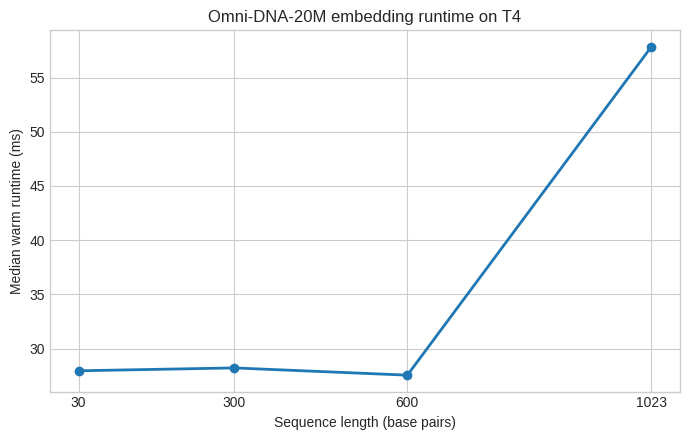

Saved: /content/drive/MyDrive/AgenticLS/figures/omnidna_20m_runtime_t4.png


In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    benchmark_df["base_length"],
    benchmark_df["runtime_median_ms"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Sequence length (base pairs)")
ax.set_ylabel("Median warm runtime (ms)")
ax.set_title("Omni-DNA-20M embedding runtime on T4")
ax.set_xticks(
    benchmark_df["base_length"]
)

fig.tight_layout()

runtime_figure = (
    FIGURE_ROOT
    / "omnidna_20m_runtime_t4.png"
)

fig.savefig(
    runtime_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
print("Saved:", runtime_figure)

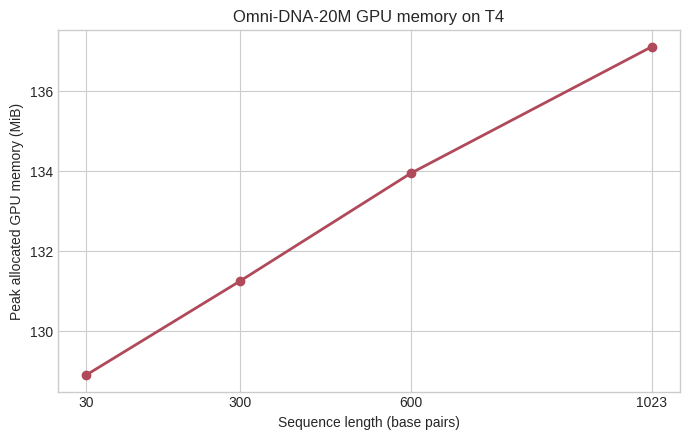

Saved: /content/drive/MyDrive/AgenticLS/figures/omnidna_20m_gpu_memory_t4.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    benchmark_df["base_length"],
    benchmark_df["peak_allocated_gpu_mib"],
    marker="o",
    linewidth=2,
    color="#B04A5A",
)

ax.set_xlabel("Sequence length (base pairs)")
ax.set_ylabel("Peak allocated GPU memory (MiB)")
ax.set_title("Omni-DNA-20M GPU memory on T4")
ax.set_xticks(
    benchmark_df["base_length"]
)

fig.tight_layout()

memory_figure = (
    FIGURE_ROOT
    / "omnidna_20m_gpu_memory_t4.png"
)

fig.savefig(
    memory_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
print("Saved:", memory_figure)

In [ ]:
import gc

# Keep benchmark_adapter; remove the earlier validation adapter.
adapter = None

for name in [
    "short_first",
    "short_cached",
    "long_first",
    "long_cached",
]:
    globals().pop(name, None)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(
    "GPU memory with one loaded adapter:",
    round(
        torch.cuda.memory_allocated() / 1024**2,
        3,
    ),
    "MiB",
)

GPU memory with one loaded adapter: 88.497 MiB


In [ ]:
import statistics

benchmark_rows = []
repetitions = 30
warmup_repetitions = 3

for base_length, sequence in benchmark_sequences.items():
    for _ in range(warmup_repetitions):
        warmup = benchmark_adapter.embed_with_info(
            sequence
        )
        assert warmup.cache_hit is False

    torch.cuda.synchronize()

    baseline_allocated_bytes = (
        torch.cuda.memory_allocated()
    )

    torch.cuda.reset_peak_memory_stats()
    elapsed_milliseconds = []

    for _ in range(repetitions):
        torch.cuda.synchronize()
        start = time.perf_counter()

        result = benchmark_adapter.embed_with_info(
            sequence
        )

        torch.cuda.synchronize()
        elapsed_milliseconds.append(
            (time.perf_counter() - start) * 1000
        )

        assert result.cache_hit is False
        assert result.embedding.shape == (256,)
        assert np.isfinite(result.embedding).all()

    peak_allocated_bytes = (
        torch.cuda.max_memory_allocated()
    )

    benchmark_rows.append(
        {
            "model": benchmark_adapter.name,
            "revision": benchmark_adapter.revision,
            "gpu": torch.cuda.get_device_name(0),
            "python": platform.python_version(),
            "pytorch": torch.__version__,
            "base_length": base_length,
            "biological_tokens": result.metadata[
                "biological_tokens"
            ],
            "window_count": result.metadata[
                "window_count"
            ],
            "raw_model_calls_per_embedding": (
                result.raw_model_calls
            ),
            "warmup_repetitions": warmup_repetitions,
            "repetitions": repetitions,
            "runtime_mean_ms": statistics.mean(
                elapsed_milliseconds
            ),
            "runtime_median_ms": statistics.median(
                elapsed_milliseconds
            ),
            "runtime_std_ms": statistics.stdev(
                elapsed_milliseconds
            ),
            "runtime_min_ms": min(
                elapsed_milliseconds
            ),
            "runtime_max_ms": max(
                elapsed_milliseconds
            ),
            "baseline_allocated_gpu_mib": (
                baseline_allocated_bytes / 1024**2
            ),
            "peak_total_allocated_gpu_mib": (
                peak_allocated_bytes / 1024**2
            ),
            "peak_incremental_gpu_mib": (
                (
                    peak_allocated_bytes
                    - baseline_allocated_bytes
                )
                / 1024**2
            ),
            "embedding_width": result.embedding.shape[0],
            "finite": bool(
                np.isfinite(result.embedding).all()
            ),
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows)
print(benchmark_df.to_string(index=False))

      model                                 revision      gpu  python      pytorch  base_length  biological_tokens  window_count  raw_model_calls_per_embedding  warmup_repetitions  repetitions  runtime_mean_ms  runtime_median_ms  runtime_std_ms  runtime_min_ms  runtime_max_ms  baseline_allocated_gpu_mib  peak_total_allocated_gpu_mib  peak_incremental_gpu_mib  embedding_width  finite
omnidna-20m 3b64e6a5ed6c8f72bad76823ce728b3045243026 Tesla T4 3.13.15 2.11.0+cu128           30                  9             1                              1                   3           30        20.614289          19.484831        5.744162       14.921741       36.695791                   88.496582                     88.822266                  0.325684              256    True
omnidna-20m 3b64e6a5ed6c8f72bad76823ce728b3045243026 Tesla T4 3.13.15 2.11.0+cu128          300                 77             1                              1                   3           30         9.772795           9.582736

In [ ]:
benchmark_df.to_csv(
    benchmark_csv,
    index=False,
)

print("Updated:", benchmark_csv)

Updated: /content/drive/MyDrive/AgenticLS/logs/model_adapters/omnidna_20m_t4_benchmark.csv


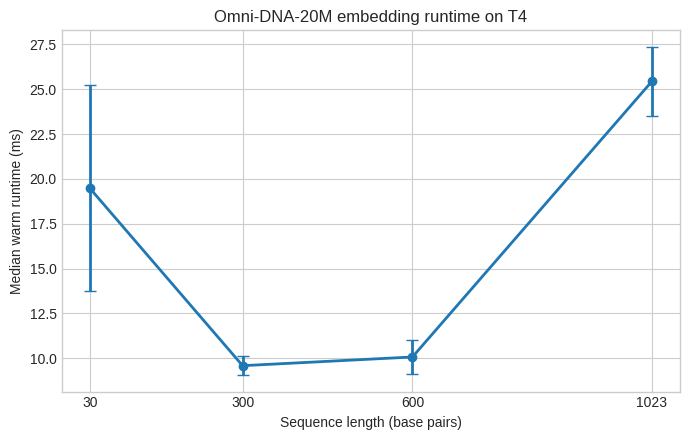

Updated: /content/drive/MyDrive/AgenticLS/figures/omnidna_20m_runtime_t4.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    benchmark_df["base_length"],
    benchmark_df["runtime_median_ms"],
    yerr=benchmark_df["runtime_std_ms"],
    marker="o",
    linewidth=2,
    capsize=4,
)

ax.set_xlabel("Sequence length (base pairs)")
ax.set_ylabel("Median warm runtime (ms)")
ax.set_title("Omni-DNA-20M embedding runtime on T4")
ax.set_xticks(benchmark_df["base_length"])

fig.tight_layout()
fig.savefig(
    runtime_figure,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Updated:", runtime_figure)

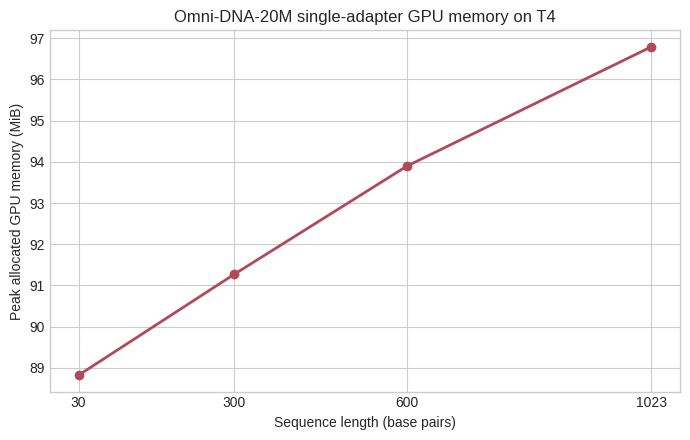

Updated: /content/drive/MyDrive/AgenticLS/figures/omnidna_20m_gpu_memory_t4.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    benchmark_df["base_length"],
    benchmark_df[
        "peak_total_allocated_gpu_mib"
    ],
    marker="o",
    linewidth=2,
    color="#B04A5A",
)

ax.set_xlabel("Sequence length (base pairs)")
ax.set_ylabel("Peak allocated GPU memory (MiB)")
ax.set_title(
    "Omni-DNA-20M single-adapter GPU memory on T4"
)
ax.set_xticks(benchmark_df["base_length"])

fig.tight_layout()
fig.savefig(
    memory_figure,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Updated:", memory_figure)

In [ ]:
import random

timings_by_length = {
    length: []
    for length in benchmark_sequences
}

benchmark_rounds = 50
rng = random.Random(42)

# Global warm-up using the largest workload.
for _ in range(10):
    benchmark_adapter.embed_with_info(
        benchmark_sequences[1023]
    )

torch.cuda.synchronize()

lengths = list(benchmark_sequences)

for round_index in range(benchmark_rounds):
    round_order = lengths.copy()
    rng.shuffle(round_order)

    for base_length in round_order:
        sequence = benchmark_sequences[base_length]

        torch.cuda.synchronize()
        start = time.perf_counter()

        result = benchmark_adapter.embed_with_info(
            sequence
        )

        torch.cuda.synchronize()

        elapsed_ms = (
            time.perf_counter() - start
        ) * 1000

        timings_by_length[base_length].append(
            elapsed_ms
        )

        assert result.cache_hit is False
        assert result.embedding.shape == (256,)
        assert np.isfinite(result.embedding).all()

print(
    {
        length: len(values)
        for length, values
        in timings_by_length.items()
    }
)

{30: 50, 300: 50, 600: 50, 1023: 50}


In [ ]:
final_rows = []

for base_length, sequence in benchmark_sequences.items():
    values = np.asarray(
        timings_by_length[base_length],
        dtype=np.float64,
    )

    # Measure memory separately from timing.
    torch.cuda.synchronize()
    baseline_bytes = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()

    memory_result = benchmark_adapter.embed_with_info(
        sequence
    )

    torch.cuda.synchronize()
    peak_bytes = torch.cuda.max_memory_allocated()

    final_rows.append(
        {
            "model": benchmark_adapter.name,
            "revision": benchmark_adapter.revision,
            "gpu": torch.cuda.get_device_name(0),
            "python": platform.python_version(),
            "pytorch": torch.__version__,
            "base_length": base_length,
            "biological_tokens": (
                memory_result.metadata[
                    "biological_tokens"
                ]
            ),
            "window_count": (
                memory_result.metadata[
                    "window_count"
                ]
            ),
            "raw_model_calls_per_embedding": (
                memory_result.raw_model_calls
            ),
            "timing_design": (
                "seeded_interleaved_random_order"
            ),
            "timing_seed": 42,
            "repetitions": benchmark_rounds,
            "runtime_mean_ms": values.mean(),
            "runtime_median_ms": np.median(values),
            "runtime_q1_ms": np.quantile(
                values,
                0.25,
            ),
            "runtime_q3_ms": np.quantile(
                values,
                0.75,
            ),
            "runtime_std_ms": values.std(ddof=1),
            "runtime_min_ms": values.min(),
            "runtime_max_ms": values.max(),
            "baseline_allocated_gpu_mib": (
                baseline_bytes / 1024**2
            ),
            "peak_total_allocated_gpu_mib": (
                peak_bytes / 1024**2
            ),
            "peak_incremental_gpu_mib": (
                (peak_bytes - baseline_bytes)
                / 1024**2
            ),
            "embedding_width": (
                memory_result.embedding.shape[0]
            ),
            "finite": bool(
                np.isfinite(
                    memory_result.embedding
                ).all()
            ),
        }
    )

benchmark_df = pd.DataFrame(final_rows)

benchmark_df.to_csv(
    benchmark_csv,
    index=False,
)

print(benchmark_df.to_string(index=False))
print("\nUpdated:", benchmark_csv)

      model                                 revision      gpu  python      pytorch  base_length  biological_tokens  window_count  raw_model_calls_per_embedding                   timing_design  timing_seed  repetitions  runtime_mean_ms  runtime_median_ms  runtime_q1_ms  runtime_q3_ms  runtime_std_ms  runtime_min_ms  runtime_max_ms  baseline_allocated_gpu_mib  peak_total_allocated_gpu_mib  peak_incremental_gpu_mib  embedding_width  finite
omnidna-20m 3b64e6a5ed6c8f72bad76823ce728b3045243026 Tesla T4 3.13.15 2.11.0+cu128           30                  9             1                              1 seeded_interleaved_random_order           42           50        13.888424          14.319216      10.206195      16.389925        3.017828        9.516456       18.596042                   88.496582                     88.822266                  0.325684              256    True
omnidna-20m 3b64e6a5ed6c8f72bad76823ce728b3045243026 Tesla T4 3.13.15 2.11.0+cu128          300                 77    

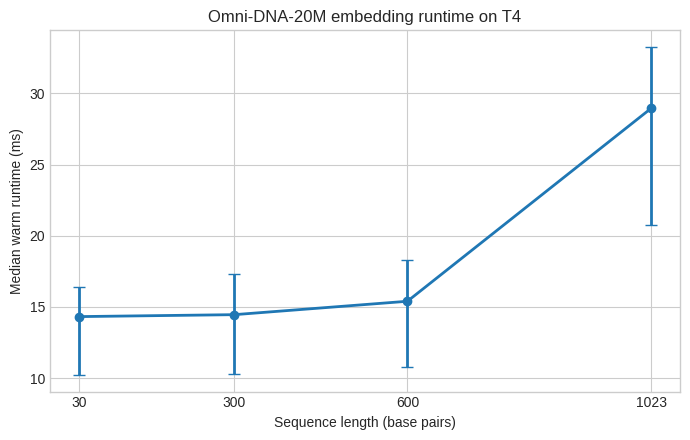

Updated: /content/drive/MyDrive/AgenticLS/figures/omnidna_20m_runtime_t4.png


In [ ]:
median = benchmark_df[
    "runtime_median_ms"
].to_numpy()

lower_error = (
    median
    - benchmark_df["runtime_q1_ms"].to_numpy()
)

upper_error = (
    benchmark_df["runtime_q3_ms"].to_numpy()
    - median
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    benchmark_df["base_length"],
    median,
    yerr=np.vstack(
        [lower_error, upper_error]
    ),
    marker="o",
    linewidth=2,
    capsize=4,
)

ax.set_xlabel("Sequence length (base pairs)")
ax.set_ylabel("Median warm runtime (ms)")
ax.set_title(
    "Omni-DNA-20M embedding runtime on T4"
)
ax.set_xticks(benchmark_df["base_length"])

fig.tight_layout()
fig.savefig(
    runtime_figure,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Updated:", runtime_figure)

In [ ]:
%cd /content/gfm-auditor

!python -m pytest -q
!git diff --check
!git status --short
!git diff --stat

/content
.................................                                        [100%]
33 passed in 0.76s
 M pyproject.toml
 M src/agenticls_auditor/models/__init__.py
?? src/agenticls_auditor/models/cache.py
?? src/agenticls_auditor/models/omnidna.py
?? tests/test_model_cache.py
?? tests/test_omnidna_adapter.py
 pyproject.toml                           |  7 +++++++
 src/agenticls_auditor/models/__init__.py | 12 ++++++++++--
 2 files changed, 17 insertions(+), 2 deletions(-)


In [ ]:
from pathlib import Path
import re

repo = Path("/content/gfm-auditor")

blocked_patterns = [
    re.compile(r"person\s*[1-4]", re.IGNORECASE),
]

text_suffixes = {
    ".py",
    ".toml",
    ".yaml",
    ".yml",
    ".md",
    ".json",
    ".jsonl",
    ".ipynb",
}

matches = []

for path in repo.rglob("*"):
    if not path.is_file():
        continue

    if ".git" in path.parts:
        continue

    if path.suffix.lower() not in text_suffixes:
        continue

    try:
        text = path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        continue

    for pattern in blocked_patterns:
        if pattern.search(text):
            matches.append(
                {
                    "file": str(path.relative_to(repo)),
                    "pattern": pattern.pattern,
                }
            )

print("Blocked-term matches:", matches)
assert matches == []

Blocked-term matches: []


In [ ]:
%cd /content/gfm-auditor

!git add \
    pyproject.toml \
    src/agenticls_auditor/models/__init__.py \
    src/agenticls_auditor/models/cache.py \
    src/agenticls_auditor/models/omnidna.py \
    tests/test_model_cache.py \
    tests/test_omnidna_adapter.py

!git diff --cached --check
!git diff --cached --stat
!git status --short

/content
 pyproject.toml                           |   7 +
 src/agenticls_auditor/models/__init__.py |  12 +-
 src/agenticls_auditor/models/cache.py    | 164 ++++++++++
 src/agenticls_auditor/models/omnidna.py  | 493 +++++++++++++++++++++++++++++++
 tests/test_model_cache.py                | 111 +++++++
 tests/test_omnidna_adapter.py            | 113 +++++++
 6 files changed, 898 insertions(+), 2 deletions(-)
M  pyproject.toml
M  src/agenticls_auditor/models/__init__.py
A  src/agenticls_auditor/models/cache.py
A  src/agenticls_auditor/models/omnidna.py
A  tests/test_model_cache.py
A  tests/test_omnidna_adapter.py


In [ ]:
import subprocess
from pathlib import Path

patch_path = Path(
    "/content/drive/MyDrive/AgenticLS/"
    "model-adapters-implementation.patch"
)

with patch_path.open("wb") as handle:
    subprocess.run(
        [
            "git",
            "diff",
            "--cached",
            "--binary",
        ],
        cwd="/content/gfm-auditor",
        stdout=handle,
        check=True,
    )

print("Saved:", patch_path)
print("Patch size:", patch_path.stat().st_size, "bytes")

Saved: /content/drive/MyDrive/AgenticLS/model-adapters-implementation.patch
Patch size: 25537 bytes
